## Machine Learning: AllLife Bank Personal Loan Campaign

## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [1]:
# Installing the libraries with the specified version.
#!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 sklearn-pandas==2.2.0 -q --user

# Import Data

import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Model Selection & Hyper Parameters
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import make_scorer

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

## Loading the dataset

In [2]:
# Load Files

from google.colab import drive
drive.mount('/content/drive')

pd_loan = pd.read_csv('/content/drive/My Drive/AIML_Class_Files/MachineLearning_Capstone/Loan_Modelling.csv')

Mounted at /content/drive


## Data Overview

* Observations
* Sanity checks

In [3]:
# Get the Spread of Data

pd_loan.head(20)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
5,6,37,13,29,92121,4,0.4,2,155,0,0,0,1,0
6,7,53,27,72,91711,2,1.5,2,0,0,0,0,1,0
7,8,50,24,22,93943,1,0.3,3,0,0,0,0,0,1
8,9,35,10,81,90089,3,0.6,2,104,0,0,0,1,0
9,10,34,9,180,93023,1,8.9,3,0,1,0,0,0,0


In [4]:
# Info on the data Set

pd_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [5]:
# Describe Data Set

pd_loan.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


In [6]:
# Confirming if Null Values exists

pd_loan.isna().value_counts()

ID     Age    Experience  Income  ZIPCode  Family  CCAvg  Education  Mortgage  Personal_Loan  Securities_Account  CD_Account  Online  CreditCard
False  False  False       False   False    False   False  False      False     False          False               False       False   False         5000
Name: count, dtype: int64

In [7]:
# Checking for duplicates
np.sum(pd_loan.duplicated()==True)

0

### Observation

1. There are 500 Rows and 14 Column.
2. All Coumns are Numeric.
3. We see Min Value of Experience as Negative. We will treat that down the line.
3. From the describe between IQR the value spread seems to be Normally distributed.
4. There are no Null or Missing Values as well as No Duplicated rows.


## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

### EDA - Data Preparation

In [8]:
# Finding out Liability Customer -
# - Customer having Securities Account OR CD Account Or Both.

sec_cust = pd_loan.loc[pd_loan['Securities_Account']==1, ['ID']].count()
cd_cust = pd_loan.loc[pd_loan['CD_Account']==1, ['ID']].count()

# Custoemr with both Securities & CD Account
sec_cd_cust = pd_loan.loc[(pd_loan['Securities_Account']==1) & (pd_loan['CD_Account']==1), ['ID']].count()

print("Securities Account:", sec_cust)
print("CD Account:", cd_cust)
print("Securities & CD Account:", sec_cd_cust)

# Total Number of Liability Customer are -

liab_cust = (sec_cust - sec_cd_cust) + (cd_cust - sec_cd_cust) + sec_cd_cust
print("\nLiability Customers:", liab_cust)


Securities Account: ID    522
dtype: int64
CD Account: ID    302
dtype: int64
Securities & CD Account: ID    147
dtype: int64

Liability Customers: ID    677
dtype: int64


### Observation
1. We have 677 Liability Customers.
2. Rest of Customer dont have any Liability with the Bank.
3. They could be associated with the Bank in form of having Loans etc..
  - But are not considerd Liability Customer.

4. So our Sample size for Target Personal Loan Campaign is 677 Customers.

In [9]:
# Extracting Liability Customer

pd_sec_cust = pd_loan.loc[pd_loan['Securities_Account']==1, pd_loan.columns]
pd_cd_cust = pd_loan.loc[pd_loan['CD_Account']==1, pd_loan.columns]

pd_liab = pd_sec_cust.merge(pd_cd_cust, how='outer')

pd_liab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 677 entries, 0 to 676
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  677 non-null    int64  
 1   Age                 677 non-null    int64  
 2   Experience          677 non-null    int64  
 3   Income              677 non-null    int64  
 4   ZIPCode             677 non-null    int64  
 5   Family              677 non-null    int64  
 6   CCAvg               677 non-null    float64
 7   Education           677 non-null    int64  
 8   Mortgage            677 non-null    int64  
 9   Personal_Loan       677 non-null    int64  
 10  Securities_Account  677 non-null    int64  
 11  CD_Account          677 non-null    int64  
 12  Online              677 non-null    int64  
 13  CreditCard          677 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 74.2 KB


### Observation
1. We get the same set of 677 Customers.
2. Our Dataset of Liability Customer is now ready for further Analysis.

In [10]:
# Findign the Spread of Liab Customers

pd_liab.head(20)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,13,48,23,114,93106,2,3.8,3,0,0,1,0,0,0
3,15,67,41,112,91741,1,2.0,1,0,0,1,0,0,0
4,20,55,28,21,94720,1,0.5,2,0,0,1,0,0,1
5,24,44,18,43,91320,2,0.7,1,163,0,1,0,0,0
6,39,42,18,141,94114,3,5.0,3,0,1,1,1,1,0
7,41,57,32,84,92672,3,1.6,3,0,0,1,0,0,0
8,48,37,12,194,91380,4,0.2,3,211,1,1,1,1,1
9,51,32,8,8,92093,4,0.7,2,0,0,1,0,1,0


In [11]:
# Describing Liability Customer

pd_liab.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,677.0,2434.079764,1441.118216,1.0,1161.0,2367.0,3684.0,4981.0
Age,677.0,45.335303,11.357874,23.0,36.0,45.0,55.0,67.0
Experience,677.0,20.112260,11.423625,-2.0,10.0,20.0,30.0,43.0
Income,677.0,83.732644,50.679096,8.0,41.0,74.0,120.0,224.0
ZIPCode,677.0,93182.957164,1762.254417,90009.0,91950.0,93555.0,94608.0,96150.0
Family,677.0,2.485968,1.145558,1.0,1.0,2.0,4.0,4.0
CCAvg,677.0,2.302600,1.969125,0.0,0.8,1.8,3.1,8.8
Education,677.0,1.892171,0.833053,1.0,1.0,2.0,3.0,3.0
Mortgage,677.0,67.110783,116.547440,0.0,0.0,0.0,110.0,589.0
Personal_Loan,677.0,0.220089,0.414613,0.0,0.0,0.0,0.0,1.0


In [12]:
# Experience is Negative, we will see what that spread is

pd_exp_neg = pd_liab.loc[pd_liab['Experience'] < 0, pd_liab.columns]
pd_exp_neg.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
61,598,24,-2,125,92835,2,7.2,1,0,0,1,0,0,1
334,3131,23,-2,82,92152,2,1.8,2,0,0,1,0,0,1
349,3293,25,-1,13,95616,4,0.4,1,0,0,1,0,0,0
404,3797,24,-2,50,94920,3,2.4,2,0,0,1,0,0,0
406,3825,23,-1,12,95064,4,1.0,1,0,0,1,0,0,1


### Observation
1. There are 6 rows out of 677 that have Negative Experience.
2. Mean Exprience is 20.
3. Negative values are -1 and -2. This could be a data entry error.
4. Looking at the Income, Education. We decided to convert Negative to Positive.  

In [13]:
# Replacing Experience Negative to Positive.
# Converting values to absolute values.

pd_liab['Experience'] = pd_liab['Experience'].abs()
np.sum(pd_liab['Experience'] < 0)

0

In [14]:
# Dropping 'ID' as it is just a Sequence Number

pd_liab.drop('ID', axis=1, inplace=True)
pd_liab.head(20)

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,48,23,114,93106,2,3.8,3,0,0,1,0,0,0
3,67,41,112,91741,1,2.0,1,0,0,1,0,0,0
4,55,28,21,94720,1,0.5,2,0,0,1,0,0,1
5,44,18,43,91320,2,0.7,1,163,0,1,0,0,0
6,42,18,141,94114,3,5.0,3,0,1,1,1,1,0
7,57,32,84,92672,3,1.6,3,0,0,1,0,0,0
8,37,12,194,91380,4,0.2,3,211,1,1,1,1,1
9,32,8,8,92093,4,0.7,2,0,0,1,0,1,0


### EDA - Data Analysis

### Univeriate Analysis

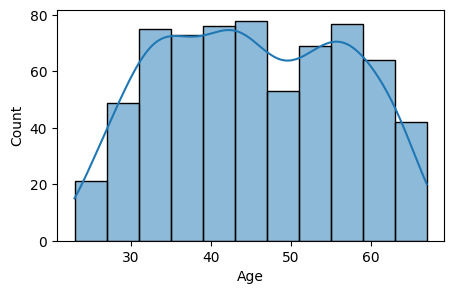

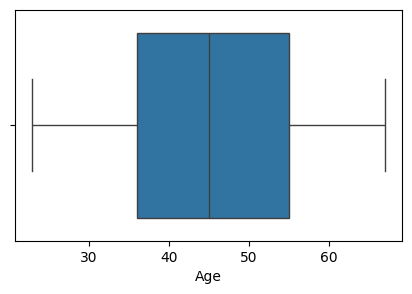

In [15]:
# Variation of Age

# Historam Plot
plt.figure(figsize=(5,3))
sns.histplot(data=pd_liab, x='Age', kde=True)
plt.show();

# Checking for Outlier usng Box plot
plt.figure(figsize=(5,3))
sns.boxplot(data=pd_liab, x='Age')
plt.show();


### Observations
1. Multi-Modal Variation.
2. There are not Outliers.
3. Most of Liability Custoemrs are in Age of 30 - 60

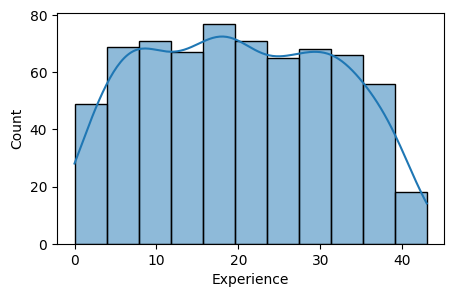

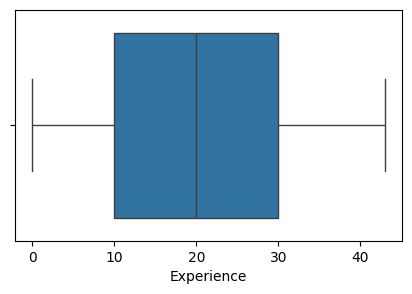

In [16]:
# Variation of Experience

# Historam Plot
plt.figure(figsize=(5,3))
sns.histplot(data=pd_liab, x='Experience', kde=True)
plt.show();

# Checking for Outlier usng Box plot
plt.figure(figsize=(5,3))
sns.boxplot(data=pd_liab, x='Experience')
plt.show();

### Observations
1. No Outliers.
2. Most of liability Customers are with Experience of 1 to 40.
3. Experinece Count of Liability Customers fairly evenly spread (Average) between 50 to 60 across all experience categories.

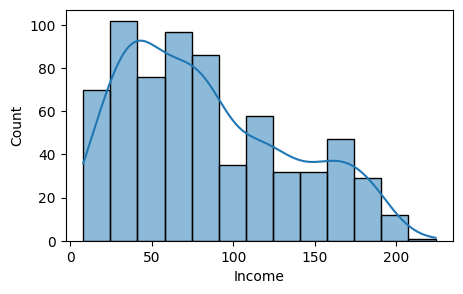

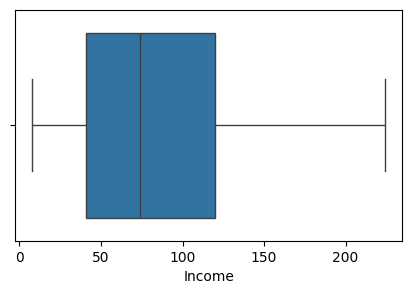

In [17]:
# Variation of Income

# Historam Plot
plt.figure(figsize=(5,3))
sns.histplot(data=pd_liab, x='Income', kde=True)
plt.show();

# Checking for Outlier usng Box plot
plt.figure(figsize=(5,3))
sns.boxplot(data=pd_liab, x='Income')
plt.show();

### Observations
1. The distribution is Right Skewed.
2. Most of the Liability Customers are with income range of 1 - 100 range.

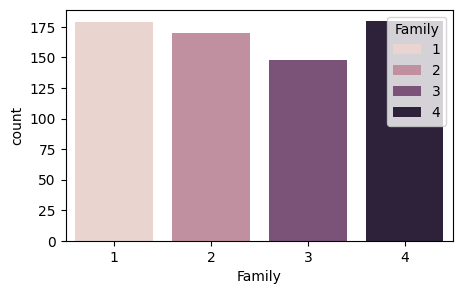

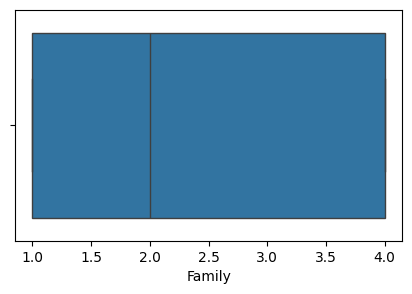

In [18]:
# Variation of Family Members

# Count Plot
plt.figure(figsize=(5,3))
sns.countplot(data=pd_liab, x='Family', hue='Family')
plt.show();

# Checking for Outlier usng Box plot
plt.figure(figsize=(5,3))
sns.boxplot(data=pd_liab, x='Family')
plt.show();

### Observations
1. The Liability Customer count are evenly spread with having family members ranging from 1 - 4.
2. Count varies across categories from 150 - 175.
3. There are no Outliers.

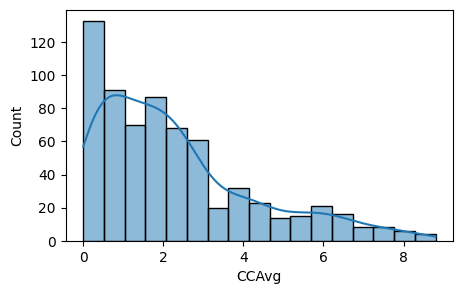

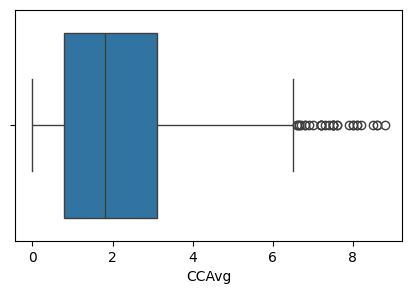

In [19]:
# Variation of Credit Card Spend

# Historam Plot
plt.figure(figsize=(5,3))
sns.histplot(data=pd_liab, x='CCAvg', kde=True)
plt.show();

# Checking for Outlier usng Box plot
plt.figure(figsize=(5,3))
sns.boxplot(data=pd_liab, x='CCAvg')
plt.show();

### Observations
1. Te distribution is Right Skewed and has outliers
2. There are small but high spenders amoung Liability Customers.
3. Median spend is close to ~2000
3. These could be potential targets for Personal Loans.

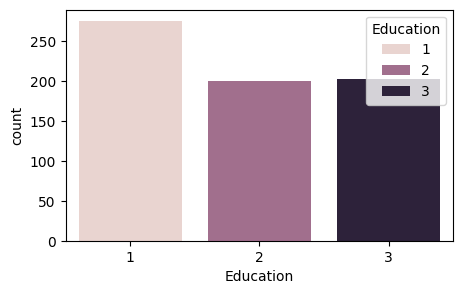

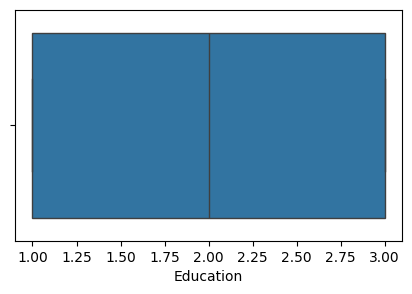

In [20]:
# Variation of Education

# Count Plot
plt.figure(figsize=(5,3))
sns.countplot(data=pd_liab, x='Education', hue='Education')
plt.show();

# Checking for Outlier usng Box plot
plt.figure(figsize=(5,3))
sns.boxplot(data=pd_liab, x='Education')
plt.show();

### Observations
1. Undergraduates top the list of Liability Customrs.
2. Graduates & Post Graduates are almost the same count of Custoemrs.

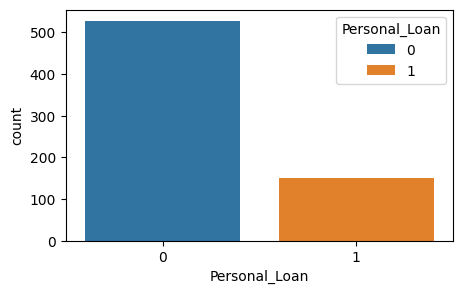

In [21]:
# Variation of Personal_Loan

# Count Plot
plt.figure(figsize=(5,3))
sns.countplot(data=pd_liab, x='Personal_Loan', hue='Personal_Loan')
plt.show();


### Observations
1. Number of Liability Customers with Personal loan is very less.
2. This is the Target Category that we want move considerable Liablity Customers to an Asset Customer.


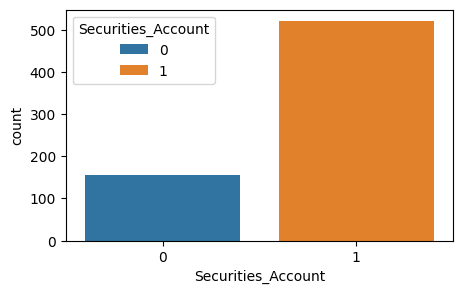

In [22]:
# Variation of Securities_Account

# Count Plot
plt.figure(figsize=(5,3))
sns.countplot(data=pd_liab, x='Securities_Account', hue='Securities_Account')
plt.show();

### Obervations
1. Liability Customers having Securities Account is predomenantly high.

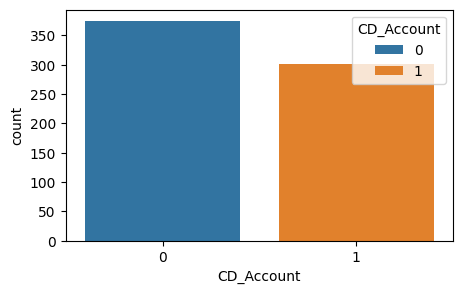

In [23]:
# Variation of CD_Account

# Count Plot
plt.figure(figsize=(5,3))
sns.countplot(data=pd_liab, x='CD_Account', hue='CD_Account')
plt.show();

### Observations
1. CD_Account holders are almost evenly split.
2. CD_Account holders are not as predomenant as Scurities_Account holder.

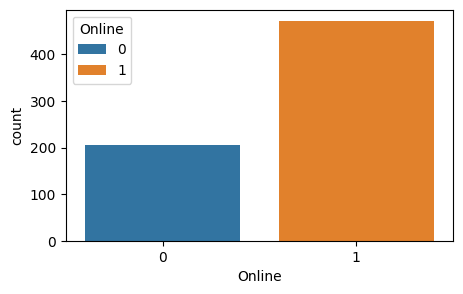

In [24]:
# Variation of Online behaviour

# Count Plot
plt.figure(figsize=(5,3))
sns.countplot(data=pd_liab, x='Online', hue='Online')
plt.show();

### Observarions
1. Majority of Liabilty Customers are Online Users.
2. Though the case that majority is not very significant, since non-Online users are 1/3 of the total population of liabiity customer base.  

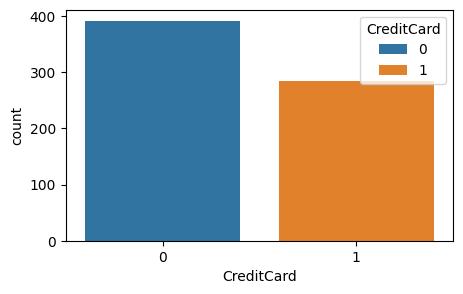

In [25]:
# Variation of Bank Vs NonBank Credit Card holders

# Count Plot
plt.figure(figsize=(5,3))
sns.countplot(data=pd_liab, x='CreditCard', hue='CreditCard')
plt.show();

### Observations
1. Majority of Liability Customers use Bank's Credit Card.
2. This difference is not so much between users of Bank's card Vs Outside Card. It is ~100.
3. Targetting Custoemrs who wants Banks Card along with Personal Loan will better deal offer could be a new revenue stream.  

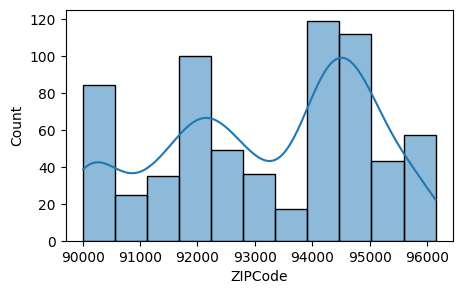

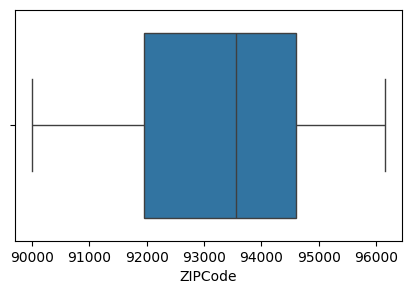

In [26]:
# Variation of Zip Code

# Historam Plot
plt.figure(figsize=(5,3))
sns.histplot(data=pd_liab, x='ZIPCode', kde=True)
plt.show();

# Checking for Outlier usng Box plot
plt.figure(figsize=(5,3))
sns.boxplot(data=pd_liab, x='ZIPCode')
plt.show();

### Observations
1. Liability Customer variation with respect to ZipCode is Left-Skewed slightly.
2. Idially the plan is to drop the ZipCode from our calculation, since typicall this doesnt influence Personal Loan.
3. Based on Mult-Variate Analysis we will see if there are any Correlation with any of teh fields, if not we will drop this in future.

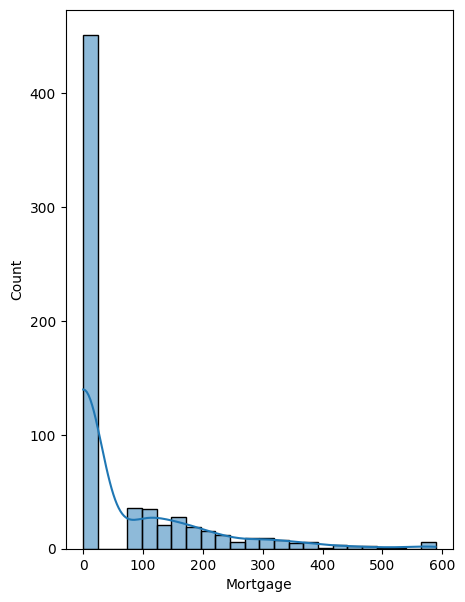

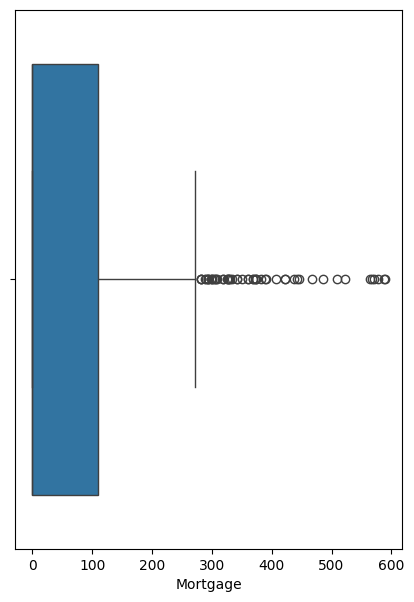

In [27]:
# Checking Variation in Mortgage

# Historam Plot
plt.figure(figsize=(5,7))
sns.histplot(data=pd_liab, x='Mortgage', kde=True)
plt.show();

# Checking for Outlier usng Box plot
plt.figure(figsize=(5,7))
sns.boxplot(data=pd_liab, x='Mortgage')
plt.show();


### Observation -
Q1 - What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?

Ans: The Mortgage has a one right tail which tells there are outliers. Most of the data are Outlier, since 75 percentile is at 100 and Max values is 600. Most of loan amount values are between 100 and 600 as seen from Histogram lot.

Count of Mortgage Before OneHot Encoding:  Mortgage    226
dtype: int64
Count of Mortgage After OneHot Encoding:  Mortgage    226
dtype: int64


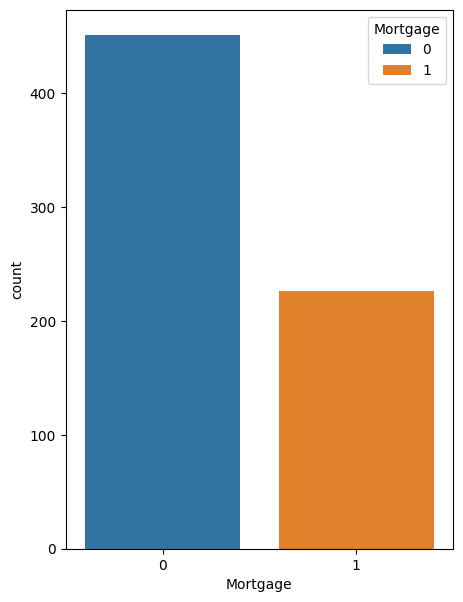

In [28]:
# From Sample of 677 Liablity Customer - we are Normalizing Mortgage using OneHot Encoding
# As part of Analysis we need to know if the Customer has taken Mortgage or Not.
# Amount of money for Mortgage is not very relevent for our analysis.

# Before OneHot Encoding of Mortgage
print("Count of Mortgage Before OneHot Encoding: ", pd_liab.loc[pd_liab['Mortgage'] > 0, ['Mortgage']].count())

#OneHot Encodign on Mortgage
pd_liab['Mortgage'] = pd_liab['Mortgage'].where(pd_liab['Mortgage'] == 0, 1)

# After OneHot Encoding of Mortgage
print("Count of Mortgage After OneHot Encoding: ", pd_liab.loc[pd_liab['Mortgage'] > 0, ['Mortgage']].count())

# Count Plot
plt.figure(figsize=(5,7))
sns.countplot(data=pd_liab, x='Mortgage', hue='Mortgage')
plt.show();


### Observation

1. We did OneHot Encoding on Mortage to set all liability Customers havong Mortgages to '1' and not having maintained 0.

2. Total Number of Custoemr from the above we an see that the count is maintained where we replace all Mortgage > 0 values with 1.


Liability Customers with External Bank Credit Card:  CreditCard    285
dtype: int64
Liability Customers with AllLife Bank Credit Card: CreditCard    392
dtype: int64


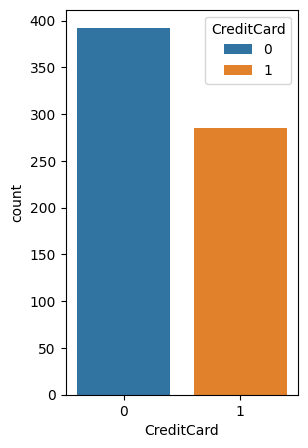

Total Customers with External Bank Credit Card: CreditCard    1470
dtype: int64
Total Customers with AllLife Bank Credit Card: CreditCard    3530
dtype: int64


In [29]:
# Number of Customers who have Credit Cards using Count Plot.

# From Sample of 677 Liablity Customer
print("Liability Customers with External Bank Credit Card: ", pd_liab.loc[pd_liab['CreditCard']==1, ['CreditCard']].count())
print("Liability Customers with AllLife Bank Credit Card:", pd_liab.loc[pd_liab['CreditCard']==0, ['CreditCard']].count())

# Count Plot for Credit Card
plt.figure(figsize=(3, 5))
sns.countplot(data=pd_liab, x='CreditCard', hue='CreditCard')
plt.show();

# From Overall Sample of 5000
print("Total Customers with External Bank Credit Card:", pd_loan.loc[pd_loan['CreditCard']==1, ['CreditCard']].count())
print("Total Customers with AllLife Bank Credit Card:", pd_loan.loc[pd_loan['CreditCard']==0, ['CreditCard']].count())


### Observation
Q2 - How many customers have credit cards?

Ans: From Liability Customer Sample of 677
  - Customers having AllLife Bank Credit Card - 392
  - Customers having External Bank Credit Card - 285

From an over all Sample size of 5000
  - Customers having AllLife Bank Credit Card - 3530
  - Customers having External Bank Credit Card - 1470


### Muti-Variate Analysis

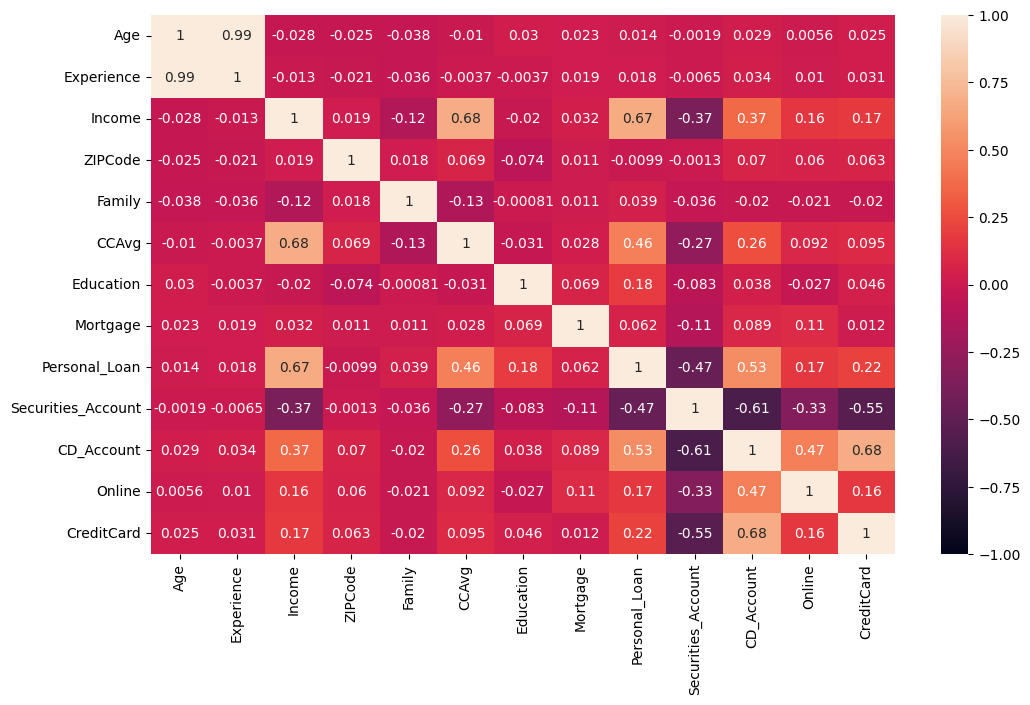

In [30]:
# Finding out Strong Correlation with Personal Loan.
# Assumption - Sample taken for this analysis is only Liability Customers - 677

# Plot Heatmap to see Correlation
plt.figure(figsize=(12, 7))
sns.heatmap(data=pd_liab.corr(), vmin=-1, vmax=1, cbar=True, annot=True)
plt.show();


### Observation
Q3. What are the attributes that have a strong correlation with the target attribute (personal loan)?

Ans: Strong Correlation in the following Order
1. Income = 0.67
2. Credi Card Spend = 0.46
3. Mortgage = 0.23
4. Credit Cards = 0.22
5. Education = 0.18


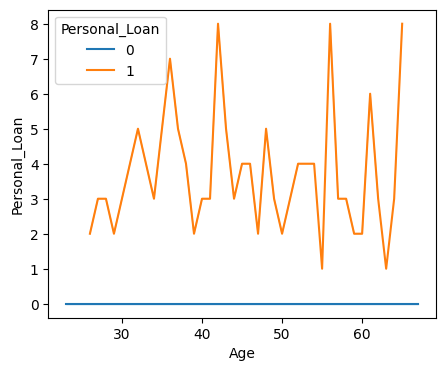

<Figure size 500x400 with 0 Axes>

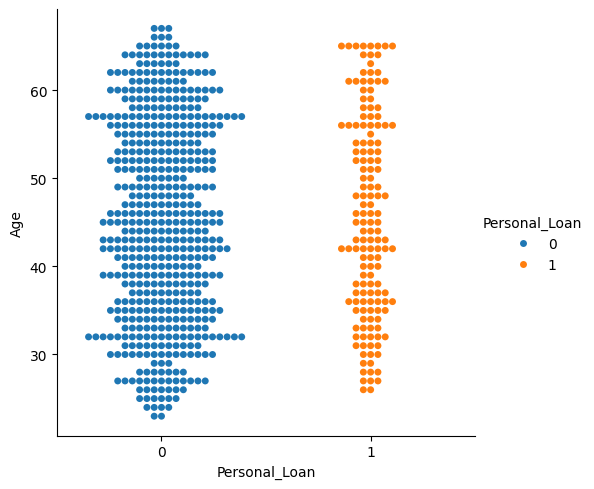

In [31]:
# Variation of Personal Loan with Age

plt.figure(figsize=(5,4))
sns.lineplot(data=pd_liab, x='Age', y='Personal_Loan', estimator='sum', hue='Personal_Loan')
plt.show();

# Swarm Plot with Liability Customers
plt.figure(figsize=(5,4))
sns.catplot(data=pd_liab, x='Personal_Loan', y='Age', kind='swarm', hue='Personal_Loan');
plt.show();


### Observation
Q4. How does a customer's interest in purchasing a loan vary with their age?

Ans: At the begining there is trend upward to buy loan
  - At Age 40 - 60 the loan purchase behaviour is flat.
  - At Age 60 - 65 number of people purchasing loan is trendign downwards.
  - We have use the enitire dataset for this calculation and NOT limited this to Liability Customer.

  - With Swarp Plot we use only the Liability Dataset and we get a spread of number of Cutomers with Loan and Not having Loan
  - Customers are spread across all Ages, with larger spread at varied distict segements like around ~40s, ~55 and ~60.

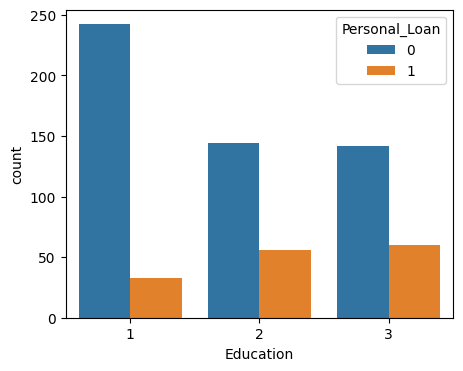

In [32]:
# Variation of Personal Loan with Education

# Count Plot on Personal Loan
plt.figure(figsize=(5,4))
sns.countplot(data=pd_liab, x='Education', hue='Personal_Loan')
plt.show();


### Observation
Q5. How does a customer's interest in purchasing a loan vary with their Education ?

Ans: As the Education Qualification increases the trend to buys loan also increases. People with advance degree seems to be having the higher number of loan.

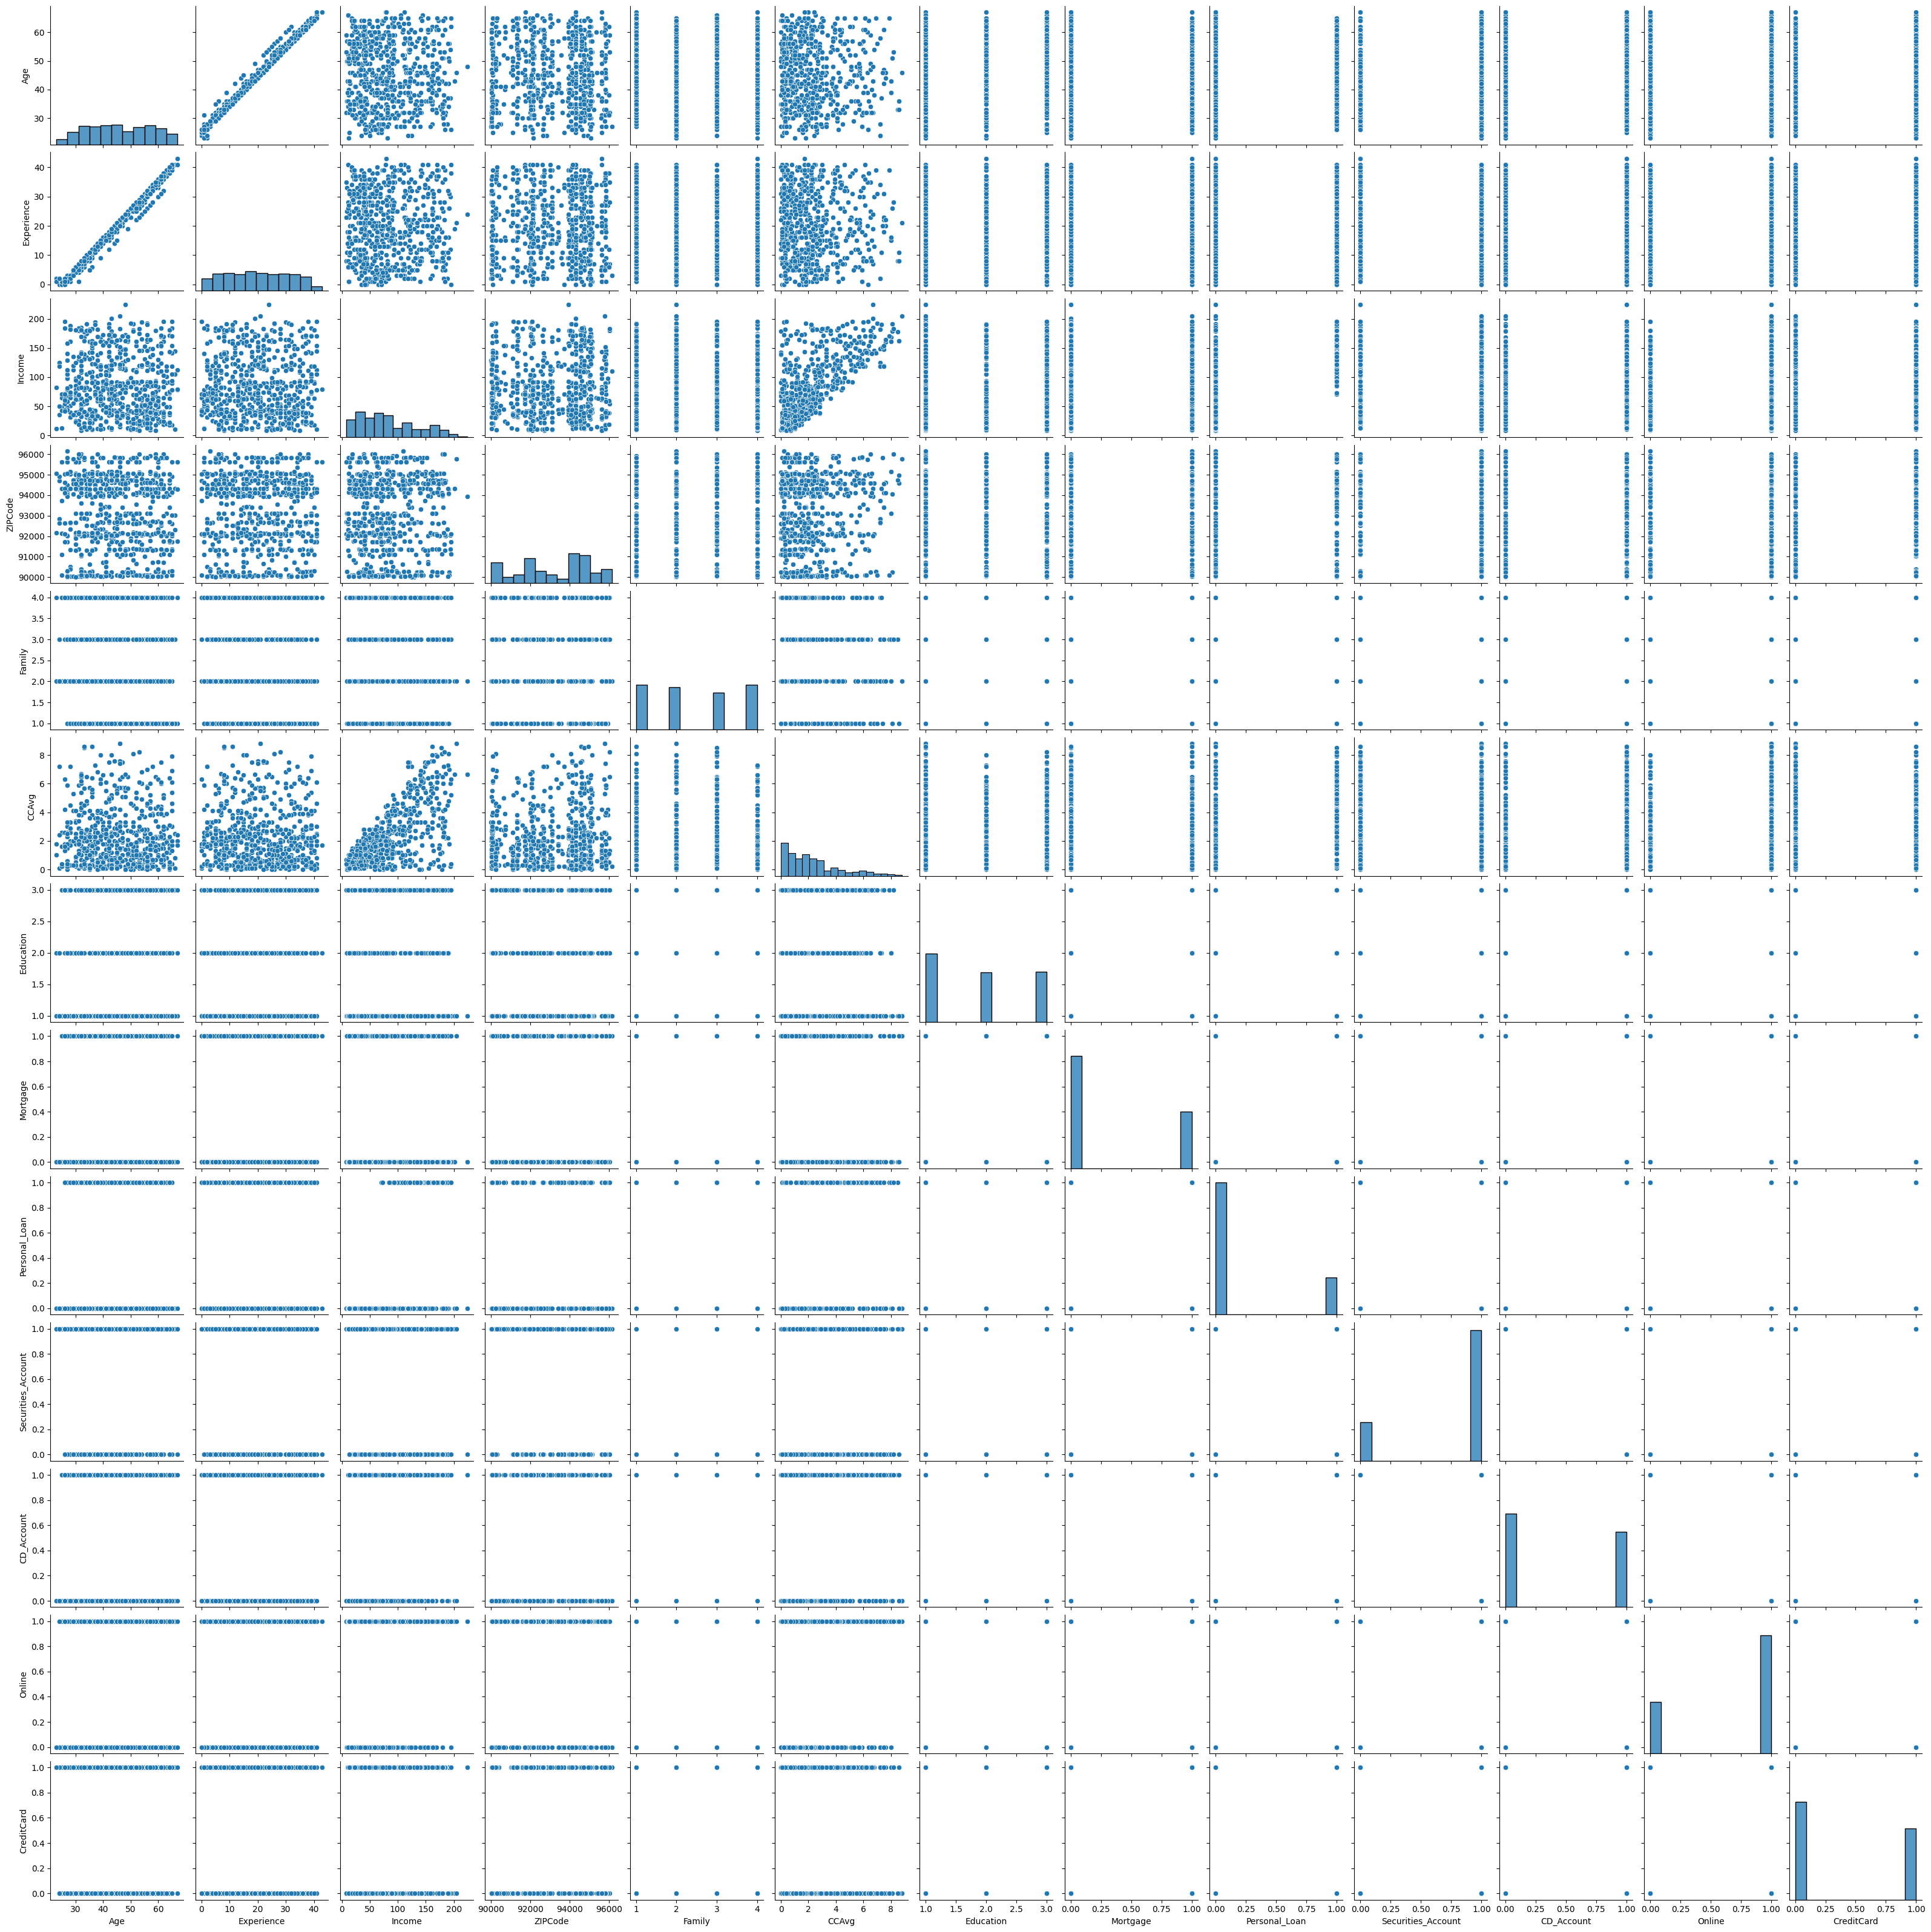

In [33]:
# Understanding Variations of Attributes
# Building PairPlot of Attributes.

plt.Figure(figsize=(5,7));
sns.pairplot(data=pd_liab,vars=pd_liab.columns);
plt.show();

### Observations
1. Strong Correlation across the several Attributes.
2. String Positive trend between Income & Credit Card Spend, Age & Experience.
3. Majority of Liability Custoemrs dont have Personal Loan.
  - This also shows clearly in rest of attributes where majority count are with Personal Loan Zero.

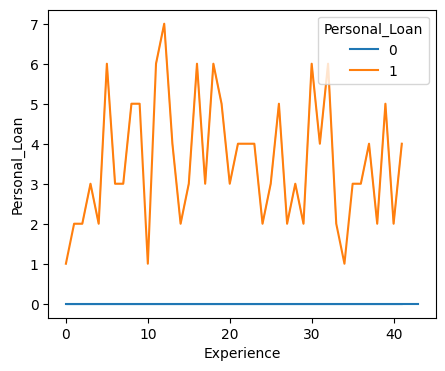

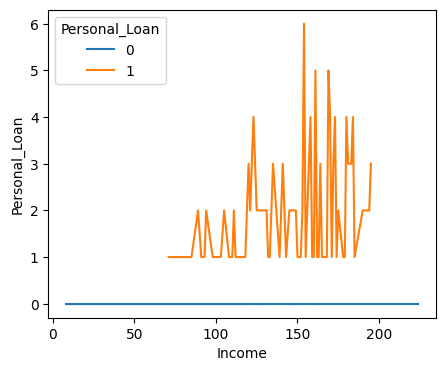

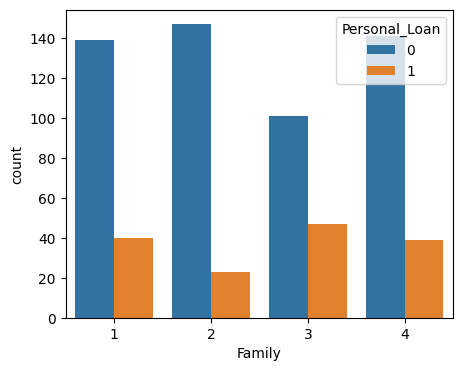

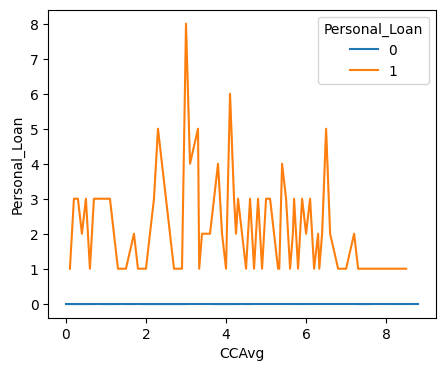

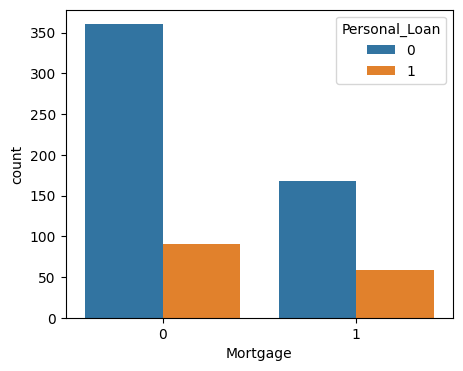

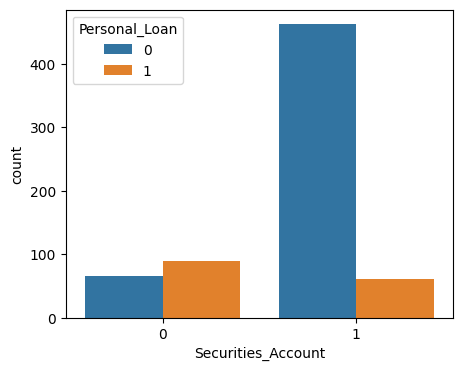

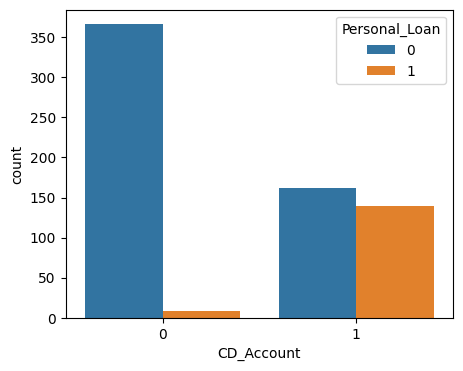

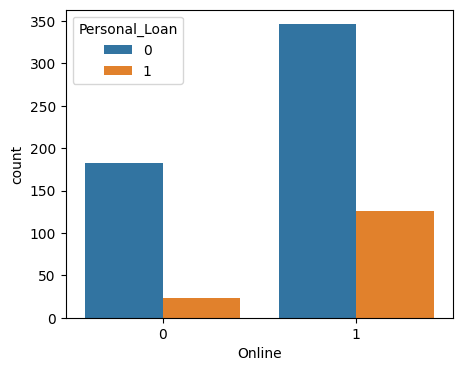

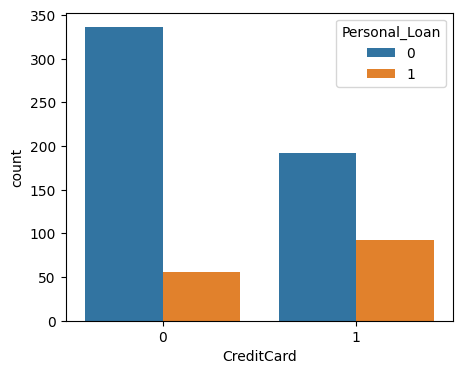

In [34]:
# Plotting other relationships all Attributes with respect to Personal Loan.
# Only Liability Custoemrs are considered in all our Visualization.

# Variation with Experience
plt.figure(figsize=(5,4))
sns.lineplot(data=pd_liab, x='Experience', y='Personal_Loan', estimator='sum', hue='Personal_Loan')
plt.show();

# Variation with Income
plt.figure(figsize=(5,4))
sns.lineplot(data=pd_liab, x='Income', y='Personal_Loan', estimator='sum', hue='Personal_Loan')
plt.show();

# Variation with Family
plt.figure(figsize=(5,4))
sns.countplot(data=pd_liab, x='Family', hue='Personal_Loan')
plt.show();

# Variation with Credit Card Average Spend
plt.figure(figsize=(5,4))
sns.lineplot(data=pd_liab, x='CCAvg', y='Personal_Loan', estimator='sum', hue='Personal_Loan')
plt.show();

# Variation with Mortgage
plt.figure(figsize=(5,4))
sns.countplot(data=pd_liab, x='Mortgage', hue='Personal_Loan')
plt.show();

# Variation with Securities Account
plt.figure(figsize=(5,4))
sns.countplot(data=pd_liab, x='Securities_Account', hue='Personal_Loan')
plt.show();

# Variation with CD Account
plt.figure(figsize=(5,4))
sns.countplot(data=pd_liab, x='CD_Account', hue='Personal_Loan')
plt.show();

# Variation with Online
plt.figure(figsize=(5,4))
sns.countplot(data=pd_liab, x='Online', hue='Personal_Loan')
plt.show();

# Variation with Online
plt.figure(figsize=(5,4))
sns.countplot(data=pd_liab, x='CreditCard', hue='Personal_Loan')
plt.show();


### Observations
1. Personal Loan with Experience - There are people across exprience lines that have taken Personal Loans. There are distinct spikes at range of 10, 20, 30 year where more number of people have take Loans.

2. Personal Loan with Income - Loan has started from people whohave higher Income like 70 and above. Higher the Income more people are taking Loans. Could be a potential attribute to target for Loan

3. Personal Loan with Family - Loan is spread across categories. But general trend is majority of Families have not taken Loan.

4. Personal Loan with CCAvg - This is an even spread. People with CCAvg between 2 & 3 have the highest Loan. Could be potential attribute to consider for Loan.

5. Personal Loan with Mortage - There are few people with Mortgage whohas take Loan. Majority of people dont have Loan nor Mortgage.

6. Personal Loan with Securities_Account - Majority of Customers are Security Customers but they havent take any Loan. Could be a potentail segment to target for Loans.

7. Personal Loan with CD_Account - Customer with CD_Account who have is less compared to Securities. Could be a potentail segment to target for Loans.

8. Personal Loan with Online - Customers who operate Online seems to have taken more Loans. Increasing Online presence can improve the opportunit for conversion to Asset Customer.

9. Personal Loan with Credit Card - Customers with Bank Credit Card can signup for more Loan

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

In [35]:
# ZipCode Column is dropped since it has weak correlation with Personal Loan

pd_liab.drop(['ZIPCode'], axis=1, inplace=True)
pd_liab.head()


,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,48,23,114,2,3.8,3,0,0,1,0,0,0
3,67,41,112,1,2.0,1,0,0,1,0,0,0
4,55,28,21,1,0.5,2,0,0,1,0,0,1


### Observation
1. ID Column was dropped earlier in the EDA.
2. ZipCode Column was dropped earlier in the EDA  

## Model Building

#### **Success Criteria**

1. Find influencing Attributes that make a Customer Buy Loan.
2. Confusion Metrics
  - TP = Customer Buy loan (Predict) / Customer Buy loan (Actual)
  - FP = Customer Buy loan (Predict) / Customer DONOT Buy loan (Actual)
  - FN = Customer DONOT Buy loan (Predict) / Customer Buy loan (Actual)
  - TN = Customer DONOT Buy loan (Predict) / Customer DONOT Buy loan (Actual)

3. Success Criteria =
  - Improve 'Precision' by reducing FP.
  - Improving 'Recall'  by reducting FN since, if our Model could predict correctly who will buy load based on parameters, TP will automatically increase.
  - Both these scenarios are benificial to bank.

4. We will target to maximise Precision in our Decision Metrix.



In [36]:
# Creating X & y variables

y = pd_liab['Personal_Loan']
X = pd_liab.drop(['Personal_Loan'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=1)

y_train.value_counts()

Personal_Loan
0    373
1    100
Name: count, dtype: int64

### Observation
1. Model has been split 'train' Vs 'test' - 70% - 30%
2. X & y parameters has been created.

In [37]:
# Creating base Decision Matrix
# NO Pre-Pruning or Post-Pruning has been applied.

decision_tree = DecisionTreeClassifier(criterion='gini', random_state=1)
decision_tree.fit(X_train, y_train)

#Calculating Accuracy
print('Accuracy Base Score Training:', decision_tree.score(X_train, y_train))
print('Accuracy Base Score Testing:', decision_tree.score(X_test, y_test))

# Build Predic Variables
y_predict_train = decision_tree.predict(X_train)
y_predict_test = decision_tree.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))


Accuracy Base Score Training: 1.0
Accuracy Base Score Testing: 0.9215686274509803
Precision Base Score Training: 1.0
Precision Base Score Testing: 0.8666666666666667
Recall Base Score Training: 1.0
Recall Base Score Testing: 0.7959183673469388


### Observations

1. Above we have build the full Decision tree  without Pre-Pruning or Post-Pruning activities.
2. The Accuracy of the Model is for Training is 1 and Testing is 92%. This is very good for now.
3. Precision is waht we are targetting and that is also high for Training dataset.
4. We will see if we can further improve the Recall if possible by pruning the Tree.

Text(0.5, 47.7222222222222, 'Predicted label')

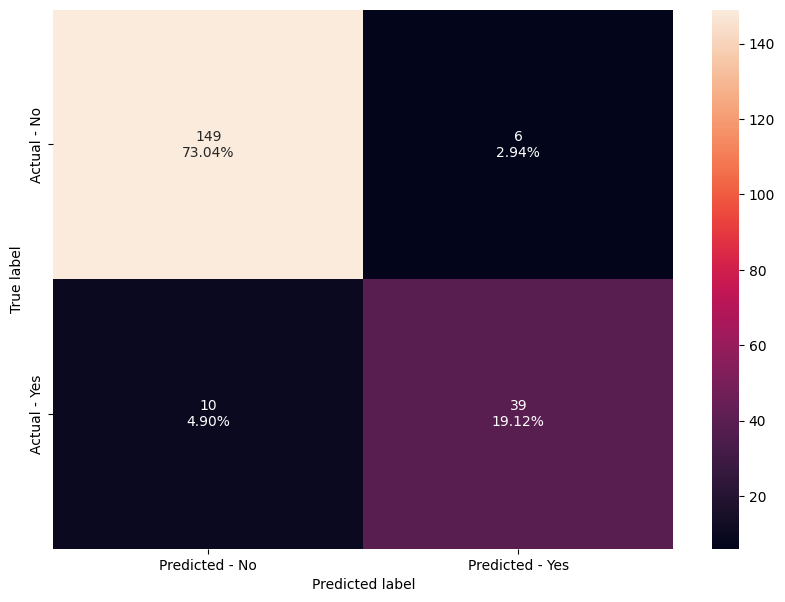

In [38]:
# Build Visualization - Confusion Metrix

cm=metrics.confusion_matrix(y_test, y_predict_test, labels=[0, 1])
df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
              columns = [i for i in ['Predicted - No','Predicted - Yes']])
group_counts = ["{0:0.0f}".format(value) for value in
            cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                      cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}" for v1, v2 in
          zip(group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)
plt.figure(figsize = (10,7))
sns.heatmap(df_cm, annot=labels,fmt='')
plt.ylabel('True label')
plt.xlabel('Predicted label')


Column Names: ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']




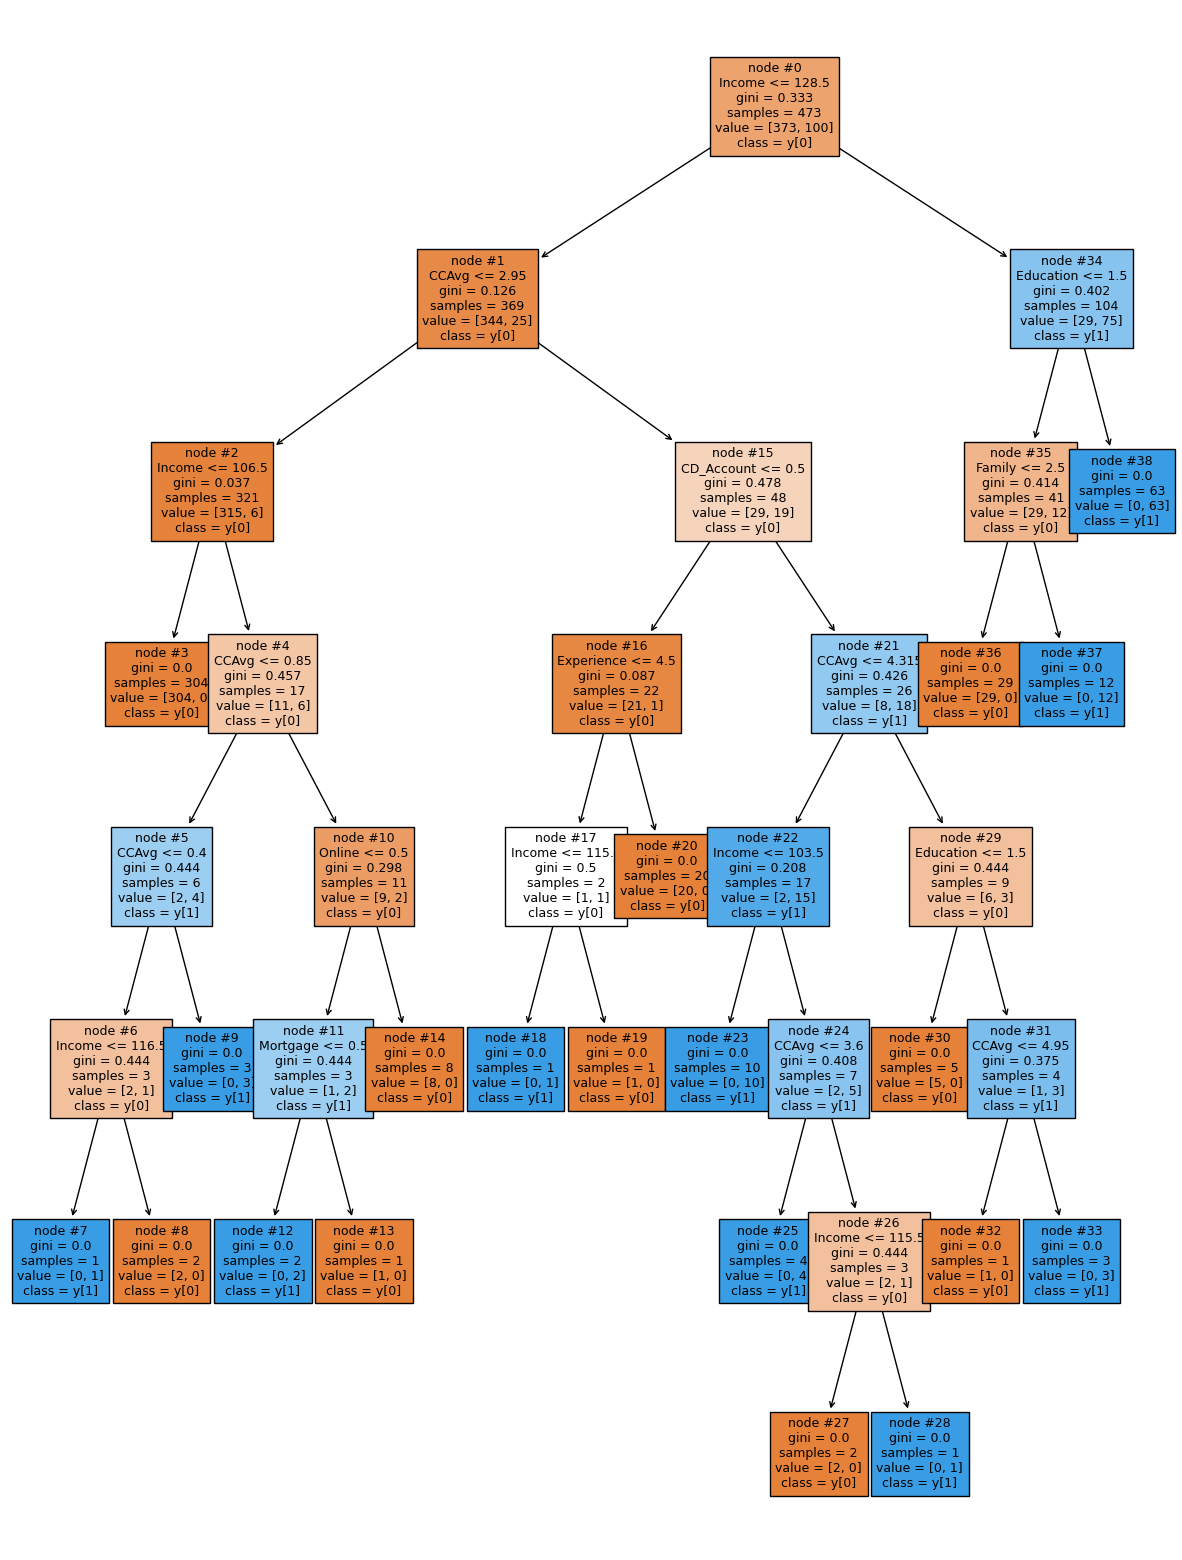

In [39]:
# Visualizing Decision Tree

X_col_list = list(X.columns)
print('Column Names:', X_col_list)
print('\n')

plt.figure(figsize=(15,20))
tree.plot_tree(decision_tree, feature_names=X_col_list, filled=True, fontsize=9, node_ids=True, class_names=True);
plt.show();

Feature Importance
                    Importance
Income                0.492194
Education             0.173421
CCAvg                 0.137008
Family                0.107634
CD_Account            0.063229
Online                0.012297
Mortgage              0.008454
Experience            0.005764
Age                   0.000000
Securities_Account    0.000000
CreditCard            0.000000


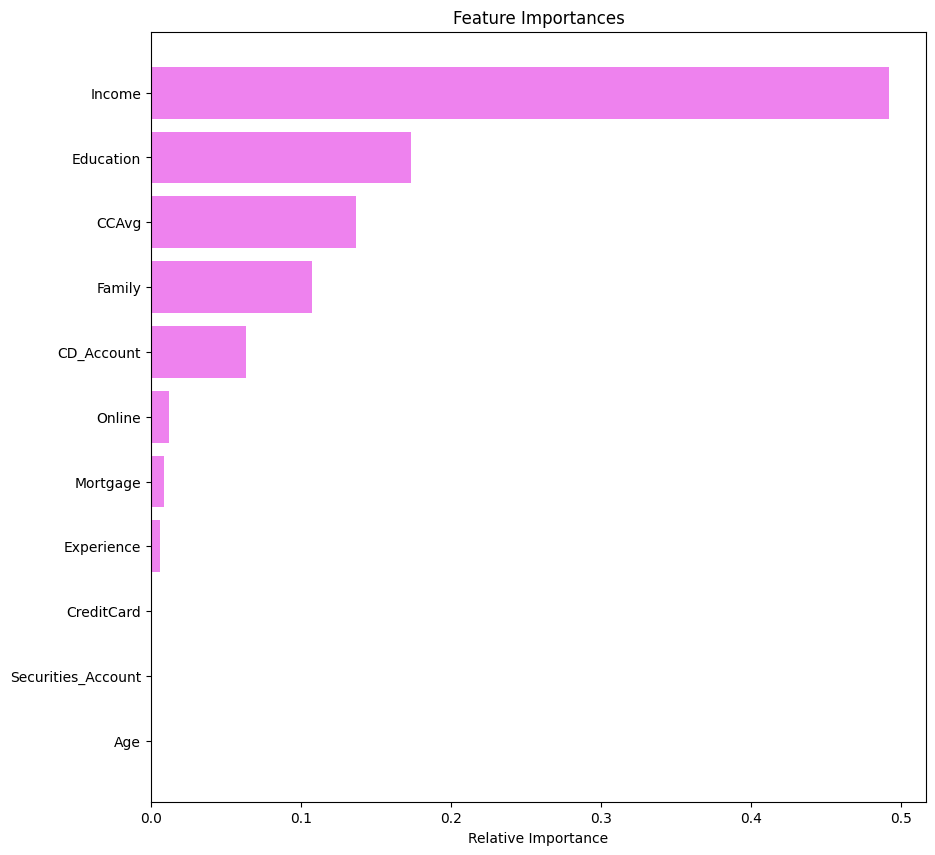

In [40]:
# Building Feature Importance

feature_importance_df = pd.DataFrame(decision_tree.feature_importances_, columns=['Importance'], index=X_train.columns).sort_values(by='Importance', ascending=False)
print('Feature Importance')
print(feature_importance_df)

feature_names = decision_tree.feature_names_in_
feature_importance = decision_tree.feature_importances_
indices = np.argsort(feature_importance)

plt.figure(figsize=(10,10))
plt.title('Feature Importances')
plt.barh(range(len(indices)), feature_importance[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show();

#### Observation

1. We have calculated the Feature Importance of the base model to predict if the individual will accept the loan
2. Potential features the model has come-up with are -  
  - Income
  - Education
  - CCAvg
  - Family
  - CD_Account.
3. Some of the prediction made from EDA and Correlation Metric (Heatmap) has been predict by the Model correctly.
4. One of the surprises is the Securitries_Accoutn holder since they are the largest in number amoun Liability Custoemers and we will see if this shows up in our feature list as we Prune the tree.   


### Model Evaluation Criterion

### **Pre-Pruning using GridSearchCV & Hyper-Parameter Tuning**

In [41]:
# Setting Hyper-Parameter
# GridSearchCV Parameter

grid_param = {'max_depth': np.arange(1,10),
              'min_samples_leaf':[1,2,5,7,10,15,20],
              'max_leaf_nodes': [2,3,5,7,10],
              'min_impurity_decrease':[0.001, 0.01, 0.1]
}

### GridSearchCV Model Tuning for Precision Scoring

In [42]:
# GridSearchCV Model Tuning for Precision Scoring

decision_tree_precision = DecisionTreeClassifier(criterion='gini', random_state=1)

precision_scorer = make_scorer(precision_score)
grid_search_cv_precision = GridSearchCV(decision_tree_precision, grid_param, scoring=precision_scorer, cv=5)
grid_search_cv_precision = grid_search_cv_precision.fit(X_train, y_train)
grid_search_cv_precision_estimator = grid_search_cv_precision.best_estimator_
grid_search_cv_precision_estimator.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, max_leaf_nodes=7,
                       min_impurity_decrease=0.001, random_state=1)

#### Observations

1. We have created GridSearchCV BestFit Estimator Model for Precision.
2. DecisionTree Hyper Parameter for Recall:
  - Max-Depth = 4
  - Max Leaf Nodes = 7
  - Gini Impurity = 0.001

In [43]:
# GridSearchCV Estmator Model Accuracy & Precision

# Calculate Accuracy
print('Accuracy GridSearchCV Estimator Model Training:', grid_search_cv_precision_estimator.score(X_train, y_train))
print('Accuracy GridSearchCV Estimator Model Testing:', grid_search_cv_precision_estimator.score(X_test, y_test))

y_train_cv_precision_predict = grid_search_cv_precision_estimator.predict(X_train)
y_test_cv_precision_predict = grid_search_cv_precision_estimator.predict(X_test)

# Calculate Precision
print("Precision on GridSearchCV Estimator Model Training:", precision_score(y_train, y_train_cv_precision_predict))
print("Precision on GridSearchCV Estimator Model Testing:", precision_score(y_test, y_test_cv_precision_predict))


Accuracy GridSearchCV Estimator Model Training: 0.9682875264270613
Accuracy GridSearchCV Estimator Model Testing: 0.9607843137254902
Precision on GridSearchCV Estimator Model Training: 0.9207920792079208
Precision on GridSearchCV Estimator Model Testing: 0.9555555555555556


### Observations

0. With HyperTuing we have removed the effect of noise / overfitting

1. HyperParameter Tuning effect for Accuracy -
  - Accuracy of Training is now reduced to 96.8% from 1
  - Accuracy of Testing is now improved to 96.0% from 92.15%
  - This says that the Prediction Accuracy for Train and Test are almost teh same, and one this is put into field the Accuracy of teh model should be close to Training if the parameters are in similar lines.

2. HyperParameter Tuning effect for Precision -
  - Preision for Training is now reduced to 92.0% from 1
  - Precision of Testing is now improved to 95.5% from 86.6%
  - This says that the BestFit model Precision has improved and False Positive (FP) will reduce.
  - One thing to note here is the Precision on Testing is more than Training. This could be because of lack of variation in Test Data and splits have not happend properly. We will see how this pans put-out when we do Post-Pruning and compare the results.

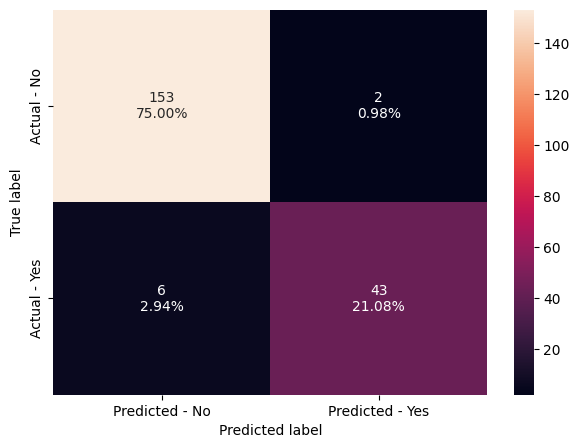

In [44]:
# Create Confusion Metrics - HyperParameter Tuning for Precision

y_test_cv_precision_predict = grid_search_cv_precision_estimator.predict(X_test)
cm = confusion_matrix(y_test, y_test_cv_precision_predict, labels=[0, 1])

df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
              columns = [i for i in ['Predicted - No','Predicted - Yes']])
group_counts = ["{0:0.0f}".format(value) for value in
            cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                      cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}" for v1, v2 in
          zip(group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=labels,fmt='');
plt.ylabel('True label');
plt.xlabel('Predicted label');

### Observations

1. Based on Precision Tuning
  - We can see that the TP has improved 19% to 21%.
  - We can see that that FP percentage has improved (2.94% reduced to 0.98%)
    - Count has reduced from 6 to 2

Column Names: ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']




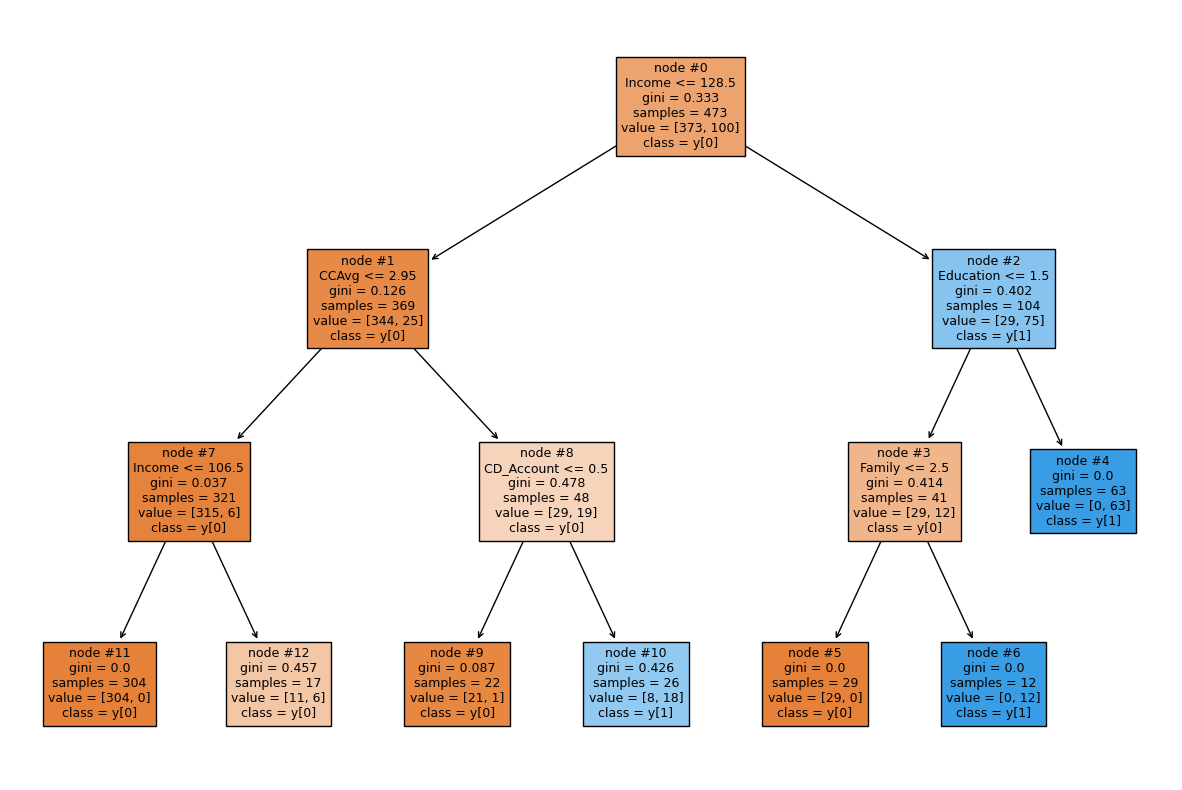

In [45]:
# Visualization of Decision Tree for Precision

X_col_list = list(X.columns)
print('Column Names:', X_col_list)
print('\n')

plt.figure(figsize=(15,10))
tree.plot_tree(grid_search_cv_precision_estimator, feature_names=X_col_list,filled=True,fontsize=9,node_ids=True,class_names=True);
plt.show();

### Observations

1. After Applying HyperTuning Paramters on Accuracy and Precision splits have happened across Features like -
  - Income
  - CCAvg
  - Education.
  - Family
  - CD_Account
  

Feature Importance
                    Importance
Income                0.535084
Education             0.181442
Family                0.123940
CCAvg                 0.086725
CD_Account            0.072809
Age                   0.000000
Experience            0.000000
Mortgage              0.000000
Securities_Account    0.000000
Online                0.000000
CreditCard            0.000000


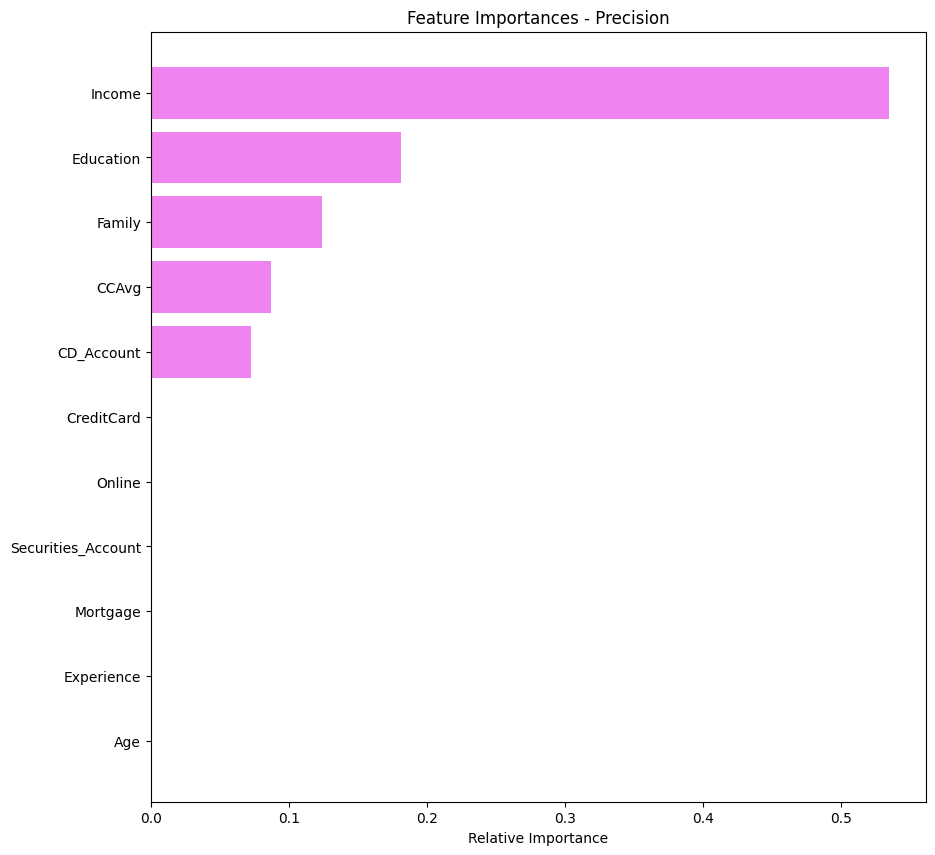

In [46]:
# Calculating the Importance Metrics for Precision

feature_importance_cv_precision = pd.DataFrame(grid_search_cv_precision_estimator.feature_importances_, columns=['Importance'], index=X_train.columns).sort_values(by='Importance', ascending=False)
print('Feature Importance')
print(feature_importance_cv_precision)

feature_names_cv_precision = grid_search_cv_precision_estimator.feature_names_in_
feature_importance_cv_precision = grid_search_cv_precision_estimator.feature_importances_
indices = np.argsort(feature_importance_cv_precision)

plt.figure(figsize=(10,10))
plt.title('Feature Importances - Precision')
plt.barh(range(len(indices)), feature_importance_cv_precision[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names_cv_precision[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show();

### Observations

1. With HyperParameter Tuning - Order of Importance has changed from base Model:
  - Income
  - Education
  - Family
  - CCAvg
  - CD_Account
2. 'Family' feature has gained prominance above 'CCAvg'

### GridSearchCV Model Tuning for Recall Scoring

In [47]:
# GridSearchCV Model Tuning for Recall Scoring

decision_tree_recall = DecisionTreeClassifier(criterion='gini', random_state=1)

recall_scorer = make_scorer(recall_score)
grid_search_cv_recall = GridSearchCV(decision_tree_recall, grid_param, scoring=recall_scorer, cv=5)
grid_search_cv_recall = grid_search_cv_recall.fit(X_train, y_train)
grid_search_cv_recall_estimator = grid_search_cv_recall.best_estimator_
grid_search_cv_recall_estimator.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, max_leaf_nodes=7,
                       min_impurity_decrease=0.001, random_state=1)

### Observations

1. We have created GridSearchCV BestFit Estimator Model for Recall.
1. DecisionTree Hyper Parameter for Recall:
  - Max-Depth= 3
  - Max Leaf Nodes = 7
  - Gini Impurity = 0.001

In [48]:
# GridSearchCV Estmator Model Accuracy & Recall

# Calculate Accuracy
print('Accuracy GridSearchCV Estimator Model Training:', grid_search_cv_recall_estimator.score(X_train, y_train))
print('Accuracy GridSearchCV Estimator Model Testing:', grid_search_cv_recall_estimator.score(X_test, y_test))

y_train_cv_recall_predict = grid_search_cv_recall_estimator.predict(X_train)
y_test_cv_recall_predict = grid_search_cv_recall_estimator.predict(X_test)

# Calculate Recall
print("Reall on GridSearchCV Estimator Model Training:", recall_score(y_train, y_train_cv_recall_predict))
print("Recall on GridSearchCV Estimator Model Testing:", recall_score(y_test, y_test_cv_recall_predict))

Accuracy GridSearchCV Estimator Model Training: 0.9682875264270613
Accuracy GridSearchCV Estimator Model Testing: 0.9607843137254902
Reall on GridSearchCV Estimator Model Training: 0.93
Recall on GridSearchCV Estimator Model Testing: 0.8775510204081632


### Observations

0. With HyperTuning we have removed the effect of noise / overfitting

1. HyperParameter Tuning effect for Accuracy -
  - Accuracy of Training is now reduced to 96.8% from 1
  - Accuracy of Testing is now improved to 96.0% from 92.15%
  - This says that the Recall Accuracy for Train and Test are almost the same, and one this is put into field the Accuracy of teh model should be close to Training if the parameters are in similar lines.
  - We can observer that the Accuracy is the same for both Scoring models.

2. HyperParameter Tuning effect for Recall -
  - Recall for Training is now reduced to 93.0% from 1
  - Recall of Testing is now improved to 87.7% from 79.59%
  - This says that the BestFit Model Recall has improved False Negatives (FN) will reduce.

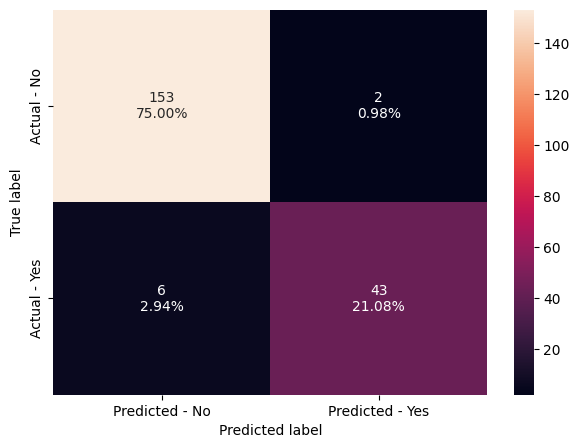

In [49]:
# Create Confusion Metrics - HyperParameter Tuning for Recall

y_test_cv_recall_predict = grid_search_cv_recall_estimator.predict(X_test)
cm = confusion_matrix(y_test, y_test_cv_recall_predict, labels=[0, 1])

df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
              columns = [i for i in ['Predicted - No','Predicted - Yes']])
group_counts = ["{0:0.0f}".format(value) for value in
            cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                      cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}" for v1, v2 in
          zip(group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=labels,fmt='');
plt.ylabel('True label');
plt.xlabel('Predicted label');

### Observations

1. Based on Recall Tuning
  - We can see that the TP has improved 19% to 21%. (Same as Precision Calculation)
  - We can see that that FN percentage has improved (4.9% reduced to 0.98%)
    - Count has reduced from 10 - 6.

Column Names: ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']




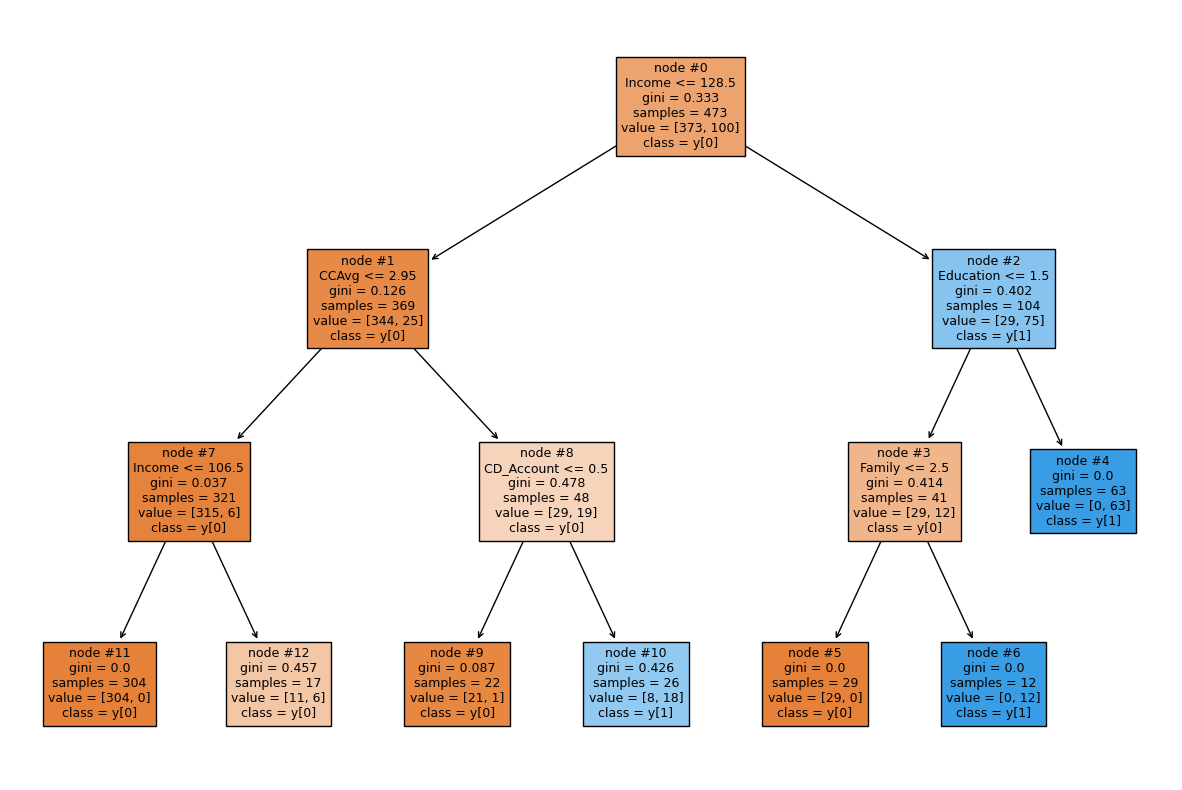

In [50]:
# Visualization of Decision Tree for Precision

X_col_list = list(X.columns)
print('Column Names:', X_col_list)
print('\n')

plt.figure(figsize=(15,10))
tree.plot_tree(grid_search_cv_recall_estimator, feature_names=X_col_list,filled=True,fontsize=9,node_ids=True,class_names=True);
plt.show();

### Observations

1. After Applying HyperTuning Paramters on Accuracy and Recall the Split have happened across top Features like -
  - Income
  - CCAvg
  - Education.
  - Family
  - CD_Account

Feature Importance
                    Importance
Income                0.535084
Education             0.181442
Family                0.123940
CCAvg                 0.086725
CD_Account            0.072809
Age                   0.000000
Experience            0.000000
Mortgage              0.000000
Securities_Account    0.000000
Online                0.000000
CreditCard            0.000000


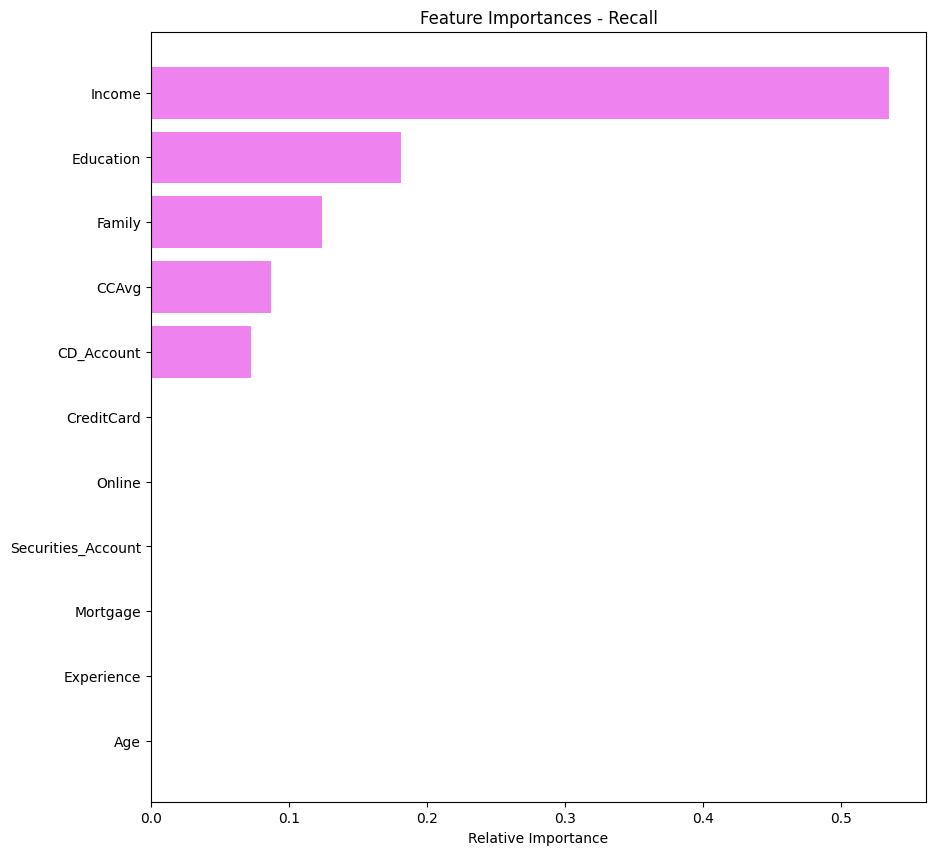

In [51]:
# Calculating the Importance Metrics for Recall

feature_importance_cv_recall = pd.DataFrame(grid_search_cv_recall_estimator.feature_importances_, columns=['Importance'], index=X_train.columns).sort_values(by='Importance', ascending=False)
print('Feature Importance')
print(feature_importance_cv_recall)

feature_names_cv_recall = grid_search_cv_recall_estimator.feature_names_in_
feature_importance_cv_recall = grid_search_cv_recall_estimator.feature_importances_
indices = np.argsort(feature_importance_cv_recall)

plt.figure(figsize=(10,10))
plt.title('Feature Importances - Recall')
plt.barh(range(len(indices)), feature_importance_cv_recall[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names_cv_recall[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show();

### Observations

1. With HyperParameter Tuning - Order of Importance has changed compared to base Model:
  - Income
  - Education
  - Family
  - CCAvg
  - CD_Account

2. 'Family' feature has gained prominance above 'CCAvg'.
3. This is simiar trend to Precision.

### **Post-Pruning using Cost-Complixity Methods**

In [52]:
# Get Cost Complexity Alphas Metric V/s Cost Complixity Impurities

decision_tree_post_prune = DecisionTreeClassifier(criterion='gini', random_state=1)
cost_complexity_prune_path = decision_tree_post_prune.cost_complexity_pruning_path(X_train, y_train)
cost_complexity_alphas, cost_complexity_impurities = cost_complexity_prune_path.ccp_alphas, cost_complexity_prune_path.impurities

pd.DataFrame(cost_complexity_prune_path)


,ccp_alphas,impurities
0,0.000000,0.000000
1,0.002018,0.004036
2,0.002487,0.011498
3,0.002819,0.017136
4,0.002819,0.019955
5,0.003171,0.023126
6,0.003980,0.031085
7,0.005285,0.036370
8,0.007500,0.043870
9,0.008480,0.052350


### Observations

1. Cost Complexity Alphas & corresponding Impurities have been caculated.

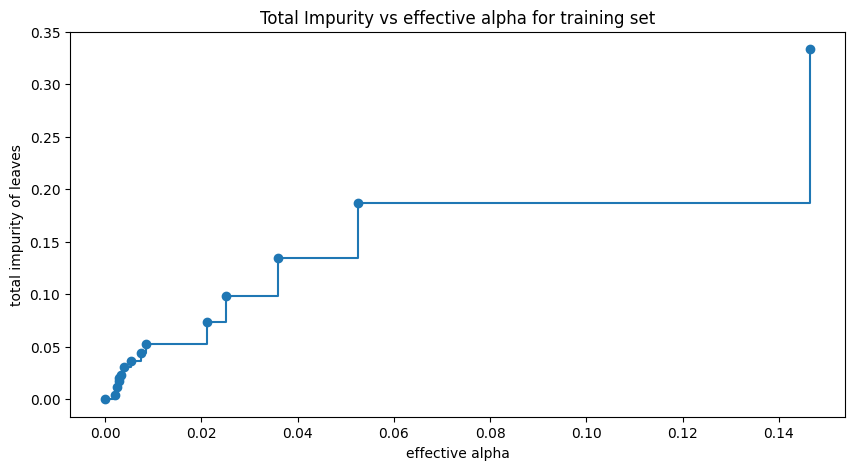

In [53]:
# Graphing CC_Alphas V/s CC_Impurities

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(cost_complexity_alphas[:], cost_complexity_impurities[:], marker='o', drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set");
plt.show();

### Observations
1. Alpha V/s Impurities has been graphed above to show the relative change.

In [54]:
# Training Each New Decision Tree after Each Prune

decision_tree_post_prune_arr = []
for ccp_alpha in cost_complexity_alphas:
    decision_tree_post_prune = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha)
    decision_tree_post_prune.fit(X_train, y_train)
    decision_tree_post_prune_arr.append(decision_tree_post_prune)
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
      decision_tree_post_prune_arr[-1].tree_.node_count, cost_complexity_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.1464636632159917


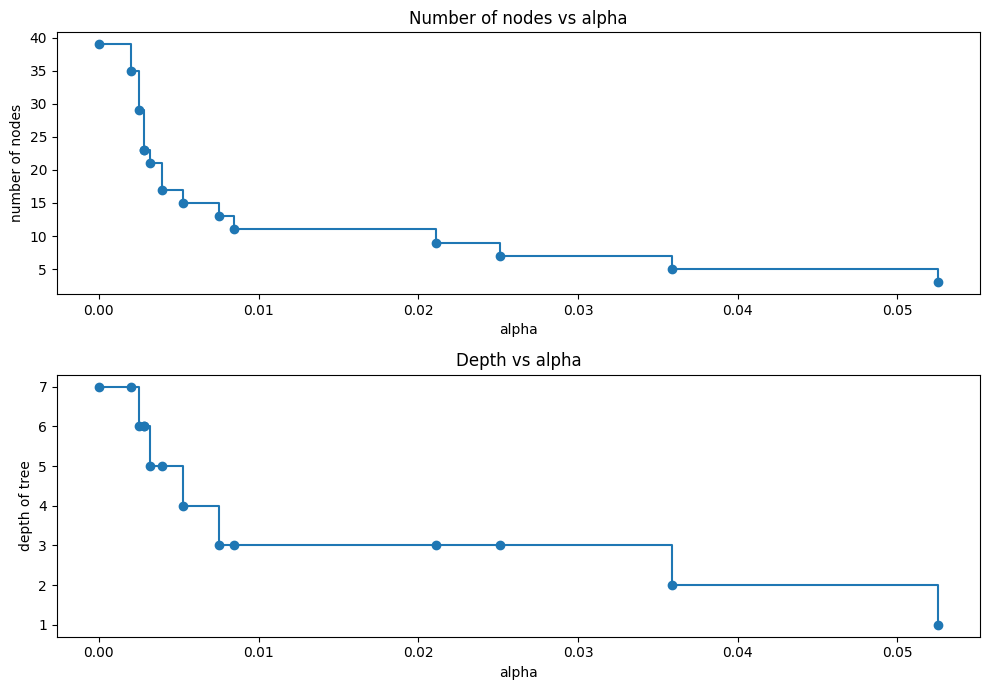

In [55]:
# Number of Nodes Vs Alpha &
# Depth of Tree Vs Alpha

decision_tree_post_prune_arr = decision_tree_post_prune_arr[:-1]
cost_complexity_alphas = cost_complexity_alphas[:-1]

node_counts = [decision_tree_post_prune.tree_.node_count for decision_tree_post_prune in decision_tree_post_prune_arr]
depth = [decision_tree_post_prune.tree_.max_depth for decision_tree_post_prune in decision_tree_post_prune_arr]
fig, ax = plt.subplots(2, 1,figsize=(10,7))
ax[0].plot(cost_complexity_alphas, node_counts, marker='o', drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(cost_complexity_alphas, depth, marker='o', drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

### Observtions

1. We see that Optimal Depth of tree is between 3 or 4
  - In Pre-Pruning when we calculated Precision Depth was 4
  - In Pre-Pruning when we calculated Recall Depth was 3
  - So Post-Pruning CC_Aplha Optimal point seems to match with Pre-Pruning parameters.
2. Similarly Nmber of nodes for the same CC_Alphs seems to be between 15 and 10.




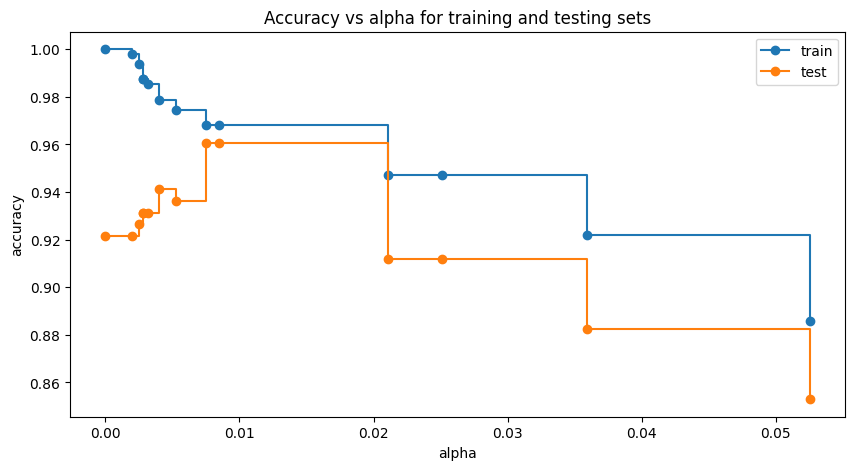

DecisionTreeClassifier(ccp_alpha=0.007500023915892589, random_state=1)
Training Accuracy of best model:  0.9682875264270613
Test Accuracy of best model:  0.9607843137254902


In [56]:
# Calculating Accuracy Variations for Individual CC_Alpha

cost_complexity_alpha_train_scores = [decision_tree_post_prune.score(X_train, y_train) for decision_tree_post_prune in decision_tree_post_prune_arr]
cost_complexity_alpha_test_scores = [decision_tree_post_prune.score(X_test, y_test) for decision_tree_post_prune in decision_tree_post_prune_arr]

# Potting the Accuracy Variation

fig, ax = plt.subplots(figsize=(10,5));
ax.set_xlabel("alpha");
ax.set_ylabel("accuracy");
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(cost_complexity_alphas, cost_complexity_alpha_train_scores, marker='o', label="train",
        drawstyle="steps-post");
ax.plot(cost_complexity_alphas, cost_complexity_alpha_test_scores, marker='o', label="test",
        drawstyle="steps-post");
ax.legend();
plt.show();

# Highest Accuracy Score and Respective Alpha

index_best_model = np.argmax(cost_complexity_alpha_test_scores)
best_model = decision_tree_post_prune_arr[index_best_model]
print(best_model)
print('Training Accuracy of best model: ',best_model.score(X_train, y_train))
print('Test Accuracy of best model: ',best_model.score(X_test, y_test))


### Observations
1. We can see that Accuracy for Optimal CC_Alpha=0.0075
  - Train = 96.8%
  - Test = 96%.
2. This is also inline with what we did for Pre-Pruning.


### Post-Pruning Model for Precision Scoring

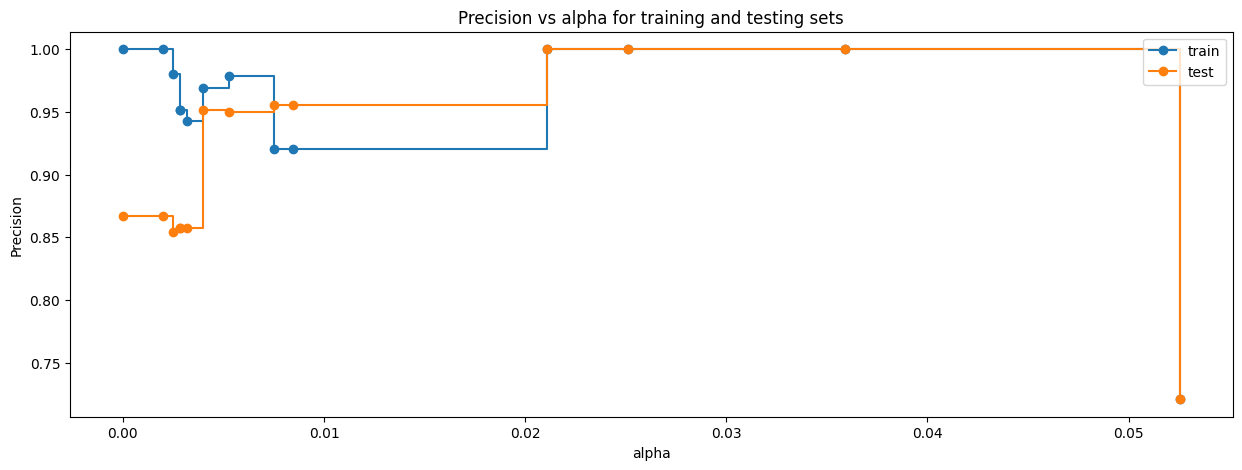

DecisionTreeClassifier(ccp_alpha=0.02108312758418467, random_state=1)
Post Pruning Precision on Training: 1.0
Post Pruning Precision on Testing: 1.0


In [57]:
# Calculating Precision for Individual Alphas

# Precision Training
precision_train=[]
for decision_tree_post_prune in decision_tree_post_prune_arr:
    predict_train_precision=decision_tree_post_prune.predict(X_train)
    values_train=precision_score(y_train,predict_train_precision)
    precision_train.append(values_train)

# Precision Testing
precision_test=[]
for decision_tree_post_prune in decision_tree_post_prune_arr:
    predict_test_precision=decision_tree_post_prune.predict(X_test)
    values_test=precision_score(y_test,predict_test_precision)
    precision_test.append(values_test)

# Graphing Precision with Alpha
fig, ax = plt.subplots(figsize=(15,5));
ax.set_xlabel("alpha");
ax.set_ylabel("Precision");
ax.set_title("Precision vs alpha for training and testing sets");
ax.plot(cost_complexity_alphas, precision_train, marker='o', label="train",
        drawstyle="steps-post");
ax.plot(cost_complexity_alphas, precision_test, marker='o', label="test",
        drawstyle="steps-post");
ax.legend();
plt.show();

# Highest Precision Score and Respective Alpha
# Choose MaxValue of Precision Test

index_best_model = np.argmax(precision_test)
best_model = decision_tree_post_prune_arr[index_best_model]
best_model_train_predict = best_model.predict(X_train)
best_model_test_predict = best_model.predict(X_test)

print(best_model)
print("Post Pruning Precision on Training:", precision_score(y_train, best_model_train_predict))
print("Post Pruning Precision on Testing:", precision_score(y_test, best_model_test_predict))

### Observations
1. We see that Precison for both Train and Testign=1
2. But our Optimal CC_Alpha is arond 0.0075.
3. Precsion at that values is aronf 95.2%.
  - This is inline with what we have in our Pre-Pruning as well.
4. We will see how Recall numbers look to see if we need to change our CC_Alpha assumptions.

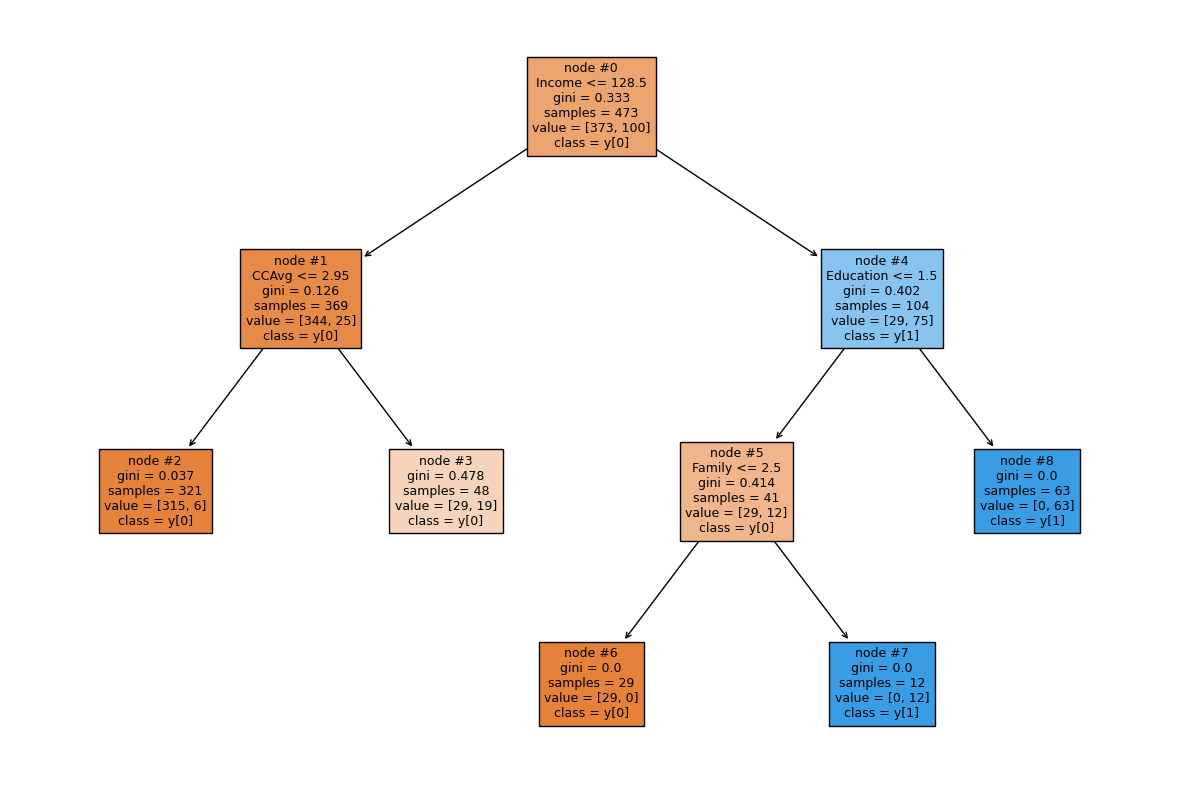

In [58]:
# Visualization of Precision Score

plt.figure(figsize=(15,10))
tree.plot_tree(best_model,feature_names=X_col_list,filled=True,fontsize=9,node_ids=True,class_names=True)
plt.show();

### Observations
1. The Feature Attributes havent changed between Pre-Pruning & Post Pruning
2. Feature Atributes are -
  - Income
  - Education
  - CCAvg
  - Family

Feature Importance
                    Importance
Income                0.563310
Education             0.202072
Family                0.138033
CCAvg                 0.096586
Age                   0.000000
Experience            0.000000
Mortgage              0.000000
Securities_Account    0.000000
CD_Account            0.000000
Online                0.000000
CreditCard            0.000000


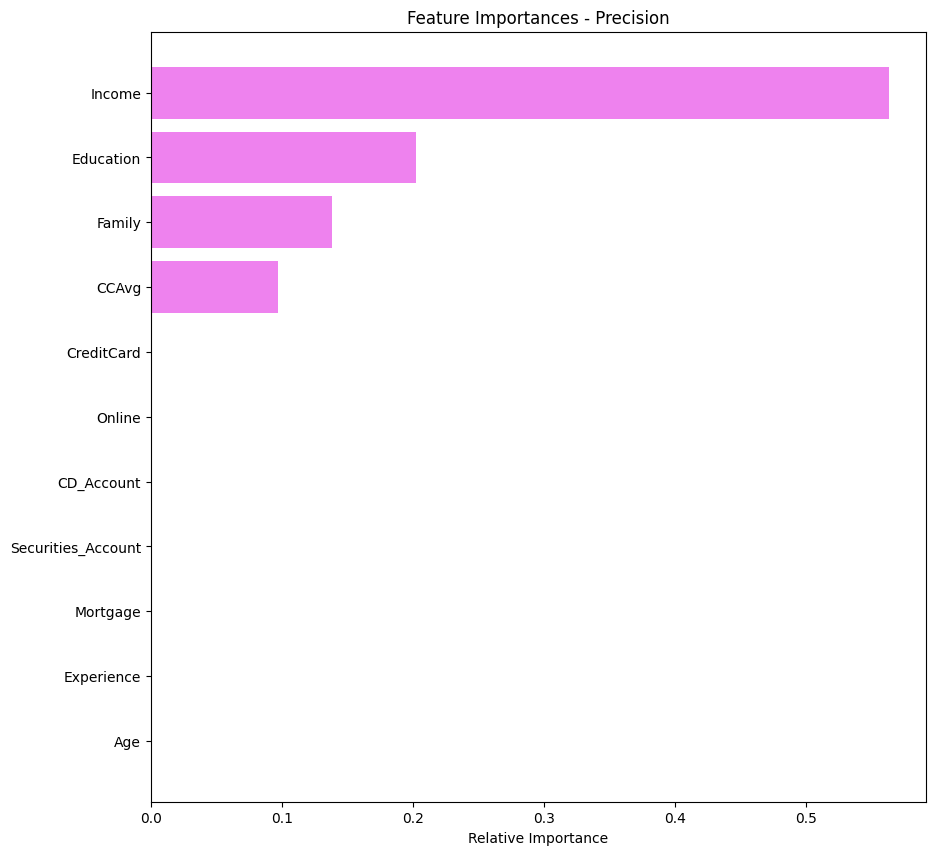

In [59]:
# Calculating the Importance Metrics for Precision

feature_best_model_post_prune_precision = pd.DataFrame(best_model.feature_importances_, columns=['Importance'], index=X_train.columns).sort_values(by='Importance', ascending=False)
print('Feature Importance')
print(feature_best_model_post_prune_precision)

# Visualizing Imporantce Graph
feature_best_model_post_prune_precision_name = best_model.feature_names_in_
feature_best_model_post_prune_precision = best_model.feature_importances_
indices = np.argsort(feature_best_model_post_prune_precision)

plt.figure(figsize=(10,10))
plt.title('Feature Importances - Precision')
plt.barh(range(len(indices)), feature_best_model_post_prune_precision[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_best_model_post_prune_precision_name[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show();


### Observations
1. The Feature Importance is inline with observations in Pre-Pruning
2. Order of Importance are
  - Income
  - Education
  - Family
  - CCAvg
3. One Observation is that CD_Account whoch was prominant in Pre-Pruning case has fallen off. But rest of order is intact between the two.



### Post-Pruning Model for Recall Scoring

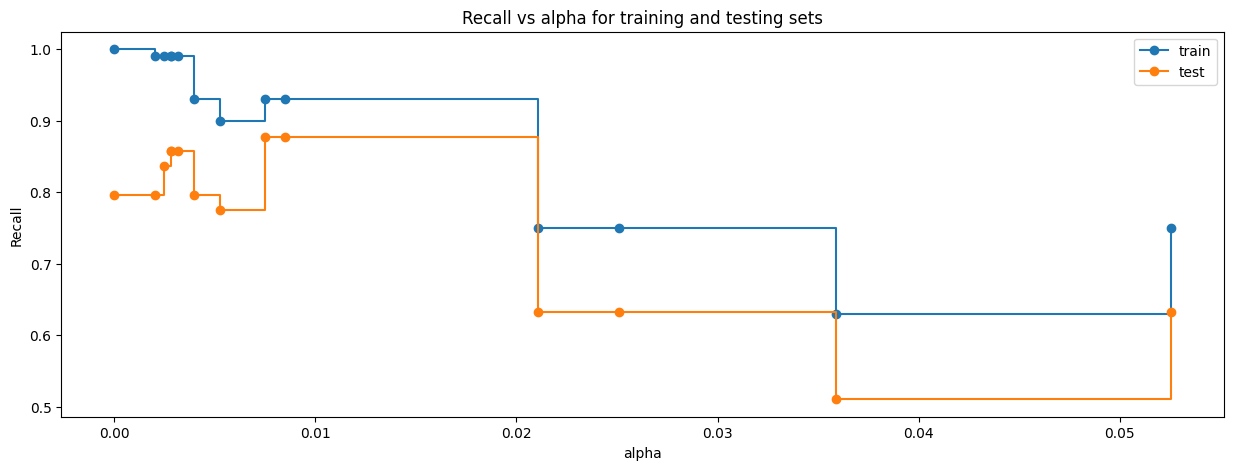

In [60]:
# Calculating Recall for Individual Alphas

# Recall Training
recall_train=[]
for decision_tree_post_prune in decision_tree_post_prune_arr:
    predict_train_recall=decision_tree_post_prune.predict(X_train)
    values_train=recall_score(y_train,predict_train_recall)
    recall_train.append(values_train)

# Recall Testing
recall_test=[]
for decision_tree_post_prune in decision_tree_post_prune_arr:
    predict_test_recall=decision_tree_post_prune.predict(X_test)
    values_test=recall_score(y_test,predict_test_recall)
    recall_test.append(values_test)

# Graphing Recall with Alpha
fig, ax = plt.subplots(figsize=(15,5));
ax.set_xlabel("alpha");
ax.set_ylabel("Recall");
ax.set_title("Recall vs alpha for training and testing sets");
ax.plot(cost_complexity_alphas, recall_train, marker='o', label="train",
        drawstyle="steps-post");
ax.plot(cost_complexity_alphas, recall_test, marker='o', label="test",
        drawstyle="steps-post");
ax.legend();
plt.show();


In [61]:
# Highest Recall Score and Respective Alpha

index_best_model = np.argmax(recall_test)
best_model = decision_tree_post_prune_arr[index_best_model]
best_model_train_predict = best_model.predict(X_train)
best_model_test_predict = best_model.predict(X_test)

print(best_model)
print("Post Pruning Recall on Training:", recall_score(y_train, best_model_train_predict))
print("Post Pruning Recall on Testing:", recall_score(y_test, best_model_test_predict))

DecisionTreeClassifier(ccp_alpha=0.007500023915892589, random_state=1)
Post Pruning Recall on Training: 0.93
Post Pruning Recall on Testing: 0.8775510204081632


### Observation
1. CC_Alpha is inline with what we found in Accuracy and Precision Calculation.
2. Recall Values 87.7% is inline with what we observed in Pre-Pruning
3. Since Recall and Precision are in line we will choose the best fit mode with CC_Alphs as 0.0075

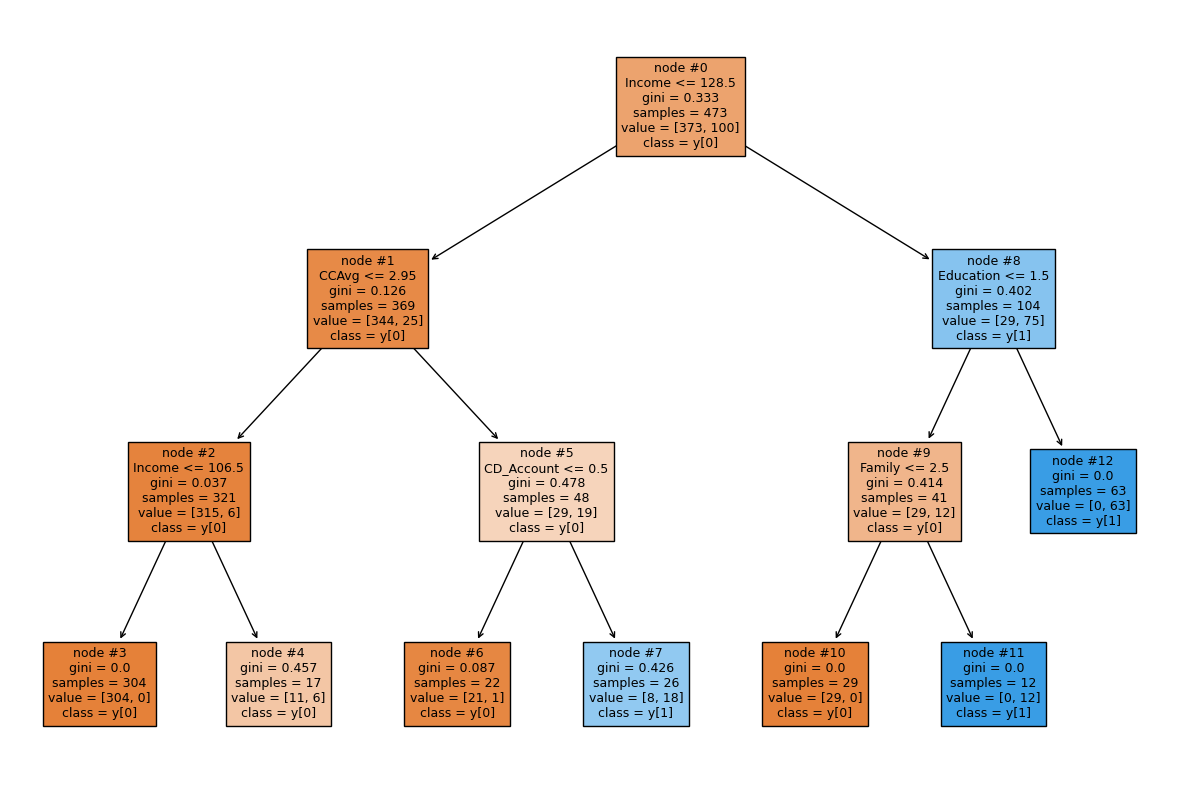

In [62]:
# Recall Tree Visualization

plt.figure(figsize=(15,10))
tree.plot_tree(best_model,feature_names=X_col_list,filled=True,fontsize=9,node_ids=True,class_names=True)
plt.show();

### Observations
1. Decison Tree Model Features for Bestfit Model -
  - Income
  - Education
  - CCAvg
  - Family
  - CD_Account
2. Interesting CD_Account that was missed in Post-Pruning has popped up when we did Recall. This shows that CD_Account should be considered for decisioning.

Feature Importance
                    Importance
Income                0.535084
Education             0.181442
Family                0.123940
CCAvg                 0.086725
CD_Account            0.072809
Age                   0.000000
Experience            0.000000
Mortgage              0.000000
Securities_Account    0.000000
Online                0.000000
CreditCard            0.000000


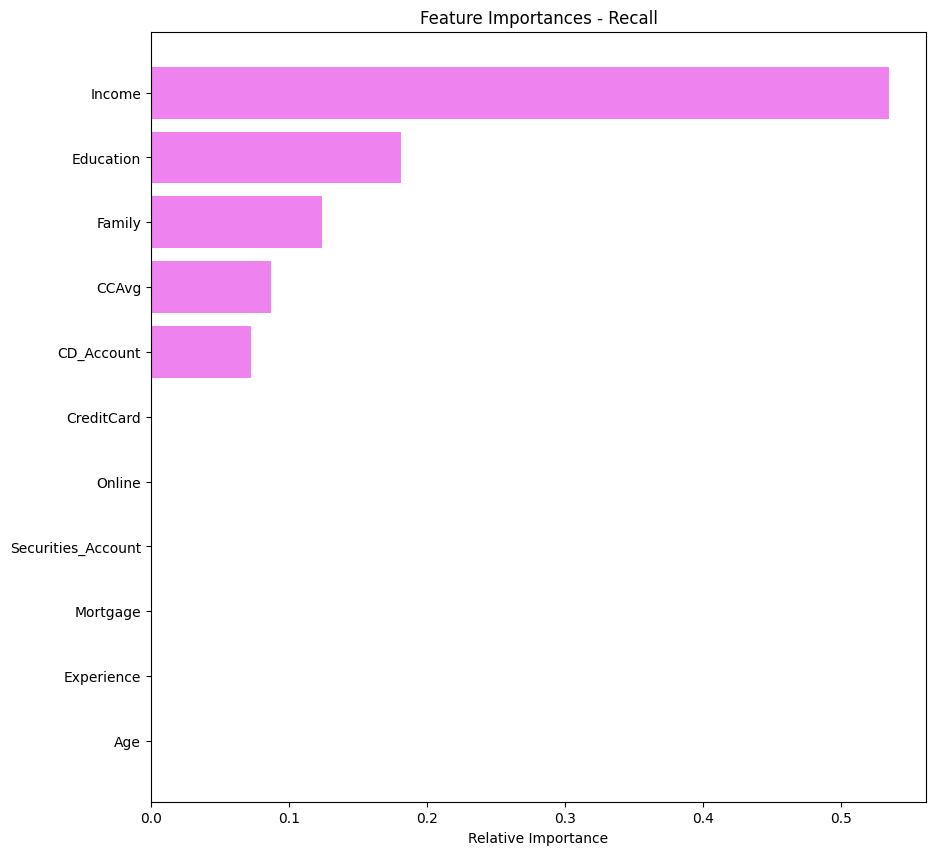

In [63]:
# Calculating the Importance Metrics for Recall

feature_best_model_post_prune_recall = pd.DataFrame(best_model.feature_importances_, columns=['Importance'], index=X_train.columns).sort_values(by='Importance', ascending=False)
print('Feature Importance')
print(feature_best_model_post_prune_recall)

# Visualizing Imporantce Graph
feature_best_model_post_prune_recall_name = best_model.feature_names_in_
feature_best_model_post_prune_recall = best_model.feature_importances_
indices = np.argsort(feature_best_model_post_prune_recall)

plt.figure(figsize=(10,10))
plt.title('Feature Importances - Recall')
plt.barh(range(len(indices)), feature_best_model_post_prune_recall[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_best_model_post_prune_recall_name[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show();


### Observations
1. We can see that the Recall Feature Importance is exactly same as what we observed in Pre-Pruning
2. Feature Importance
  - Income
  - Education
  - Family
  - CCAvg
  - CD_Account
3. As mentioned we see CD_Account showing up in Post-Pruning Recall Score compared to Precison Score in Post-Prune.

## Model Comparison and Final Model Selection

Below are the Comparison Results:

1. Original Model
  - Train Score (Accuracy): 1.0
  - Test Score (Accuracy): 0.9215686274509803
  - Recall on Training: 1.0
  - Recall on Testing: 0.7959183673469388
  - Precision on Training: 1.0
  - Precision on Testing: 8666666666666667

2. GridSearchCV HyperParameter Tuning for Accuracy & Precision
  - Train Score (Accuracy): 0.9682875264270613
  - Test Score (Accuracy): 0.9607843137254902
  - Precision on Training: 0.9207920792079208
  - Precision on Testing: 0.9555555555555556

3. GridSearchCV Hyper Parameter Tuning for Accuracy & Recall
  - Train Score (Accuracy): 0.9682875264270613
  - Test Score (Accuracy): 0.9607843137254902
  - Recall on Training: 0.93
  - Recall on Testing: 0.8775510204081632

4. Post Pruning
  - DecisionTreeClassifier(ccp_alpha=0.007500023915892589, random_state=1)
  - Train Score (Accuracy): 0.9682875264270613
  - Test Score (Accuracy): 0.9607843137254902
  - Recall on Training: 0.93
  - Recall on Testing: 0.8775510204081632
  - Precision on Training: 0.97
  - Precision on Testing: 0.953



## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?

### Recommendations

1. For Liability customers bank need to target is with high values of -
  - Income
  - Education
  - Family
  - CCAvg.
  - CD_Account
2. Also amoung the Liability Customers we have Customers with CD_Account being prominant. These customer specifically need to be targetted for conversion.
3. In our EDA analysis we see that Securitied Customers majority of Liability customers. but that doesnt show up in decision classification features.
  - Based on the insights on data distribution it would be better to consider this category of customers as well.



___